# Spectral curves: the Stieltjes transform as geometry

Figures for the notes on algebraicity, one section per section there. Nothing is drawn by hand:
- curves come from solving the actual equations;
- histograms come from sampling actual random matrices, or the eigenvalue log-gas;
- the counts come from enumeration and from topological recursion.

The code lives in `physics/spectral_curves.py`. Each figure is a single call, so you can change the arguments and rerun.

**Conventions.** $s(z) = \int \frac{\rho(x)\,dx}{x - z} \sim -\frac1z$ as in the notes, and $G = -s$ is the Cauchy transform of free probability and the loop equations. Inversion: $\rho(x) = \frac1\pi \operatorname{Im} s(x + i0)$. Random matrices are scaled so their spectra fill $[-2, 2]$.

**Colors mean the same thing everywhere.**
- **Orange** marks the cuts, the imaginary points of the curve. That is where the eigenvalues sit, so the density is drawn in orange too.
- **Blue** marks the real points of the curve, which lie over the real axis away from the support.
- **Aqua and violet tints** are sheet I (the physical sheet, where the actual Stieltjes transform lives) and sheet II.
- **Phase portraits** use hue for $\arg$ (red on the positive reals), with a brightness step at every doubling of the modulus. At a zero or a pole every hue meets, and the colors wind in opposite directions around the two.

The whole notebook runs in about two minutes.

In [1]:
from pathlib import Path
import sys
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "physics" / "spectral_curves.py").exists())
sys.path.insert(0, str(root))

import numpy as onp
import sympy as sp
import matplotlib.pyplot as plt
from IPython.display import HTML, Markdown, display

from physics import spectral_curves as sc
from plotting import spectral_curves as plot_sc

%config InlineBackend.figure_format = 'retina'
sc.use_style()
rng = onp.random.default_rng(0)

## 1. The semicircle as a curve

Solving $s^2 + zs + 1 = 0$ for $z$ gives $z = -(s + 1/s)$. So the curve *is* a copy of the $s$-sphere: it is rational, of genus 0. Over each $z$ lie the two points $s$ and $1/s$, because the two roots have product 1.

**Figure 1.1: the Joukowski map.** What to look for:
- **Two to one.** The circles $|s| = r$ and $|s| = 1/r$ land on the same ellipse. Each region, $|s| < 1$ and $|s| > 1$, covers the $z$-plane exactly once. These two regions are the two sheets.
- **The cut.** The unit circle (orange) is squashed onto $[-2, 2]$, since $e^{i\theta} \mapsto -2\cos\theta$. Its upper and lower halves become the two edges of the cut.
- **Branch points.** The map folds at $s = \pm1$, where $dz/ds = 1/s^2 - 1 = 0$. Those fold points become the branch points $z = \mp 2$.
- **Which sheet is the transform.** $s \sim -1/z$ at infinity puts $z = \infty$ at the center of the disk. So the Stieltjes transform is the disk $|s| < 1$.

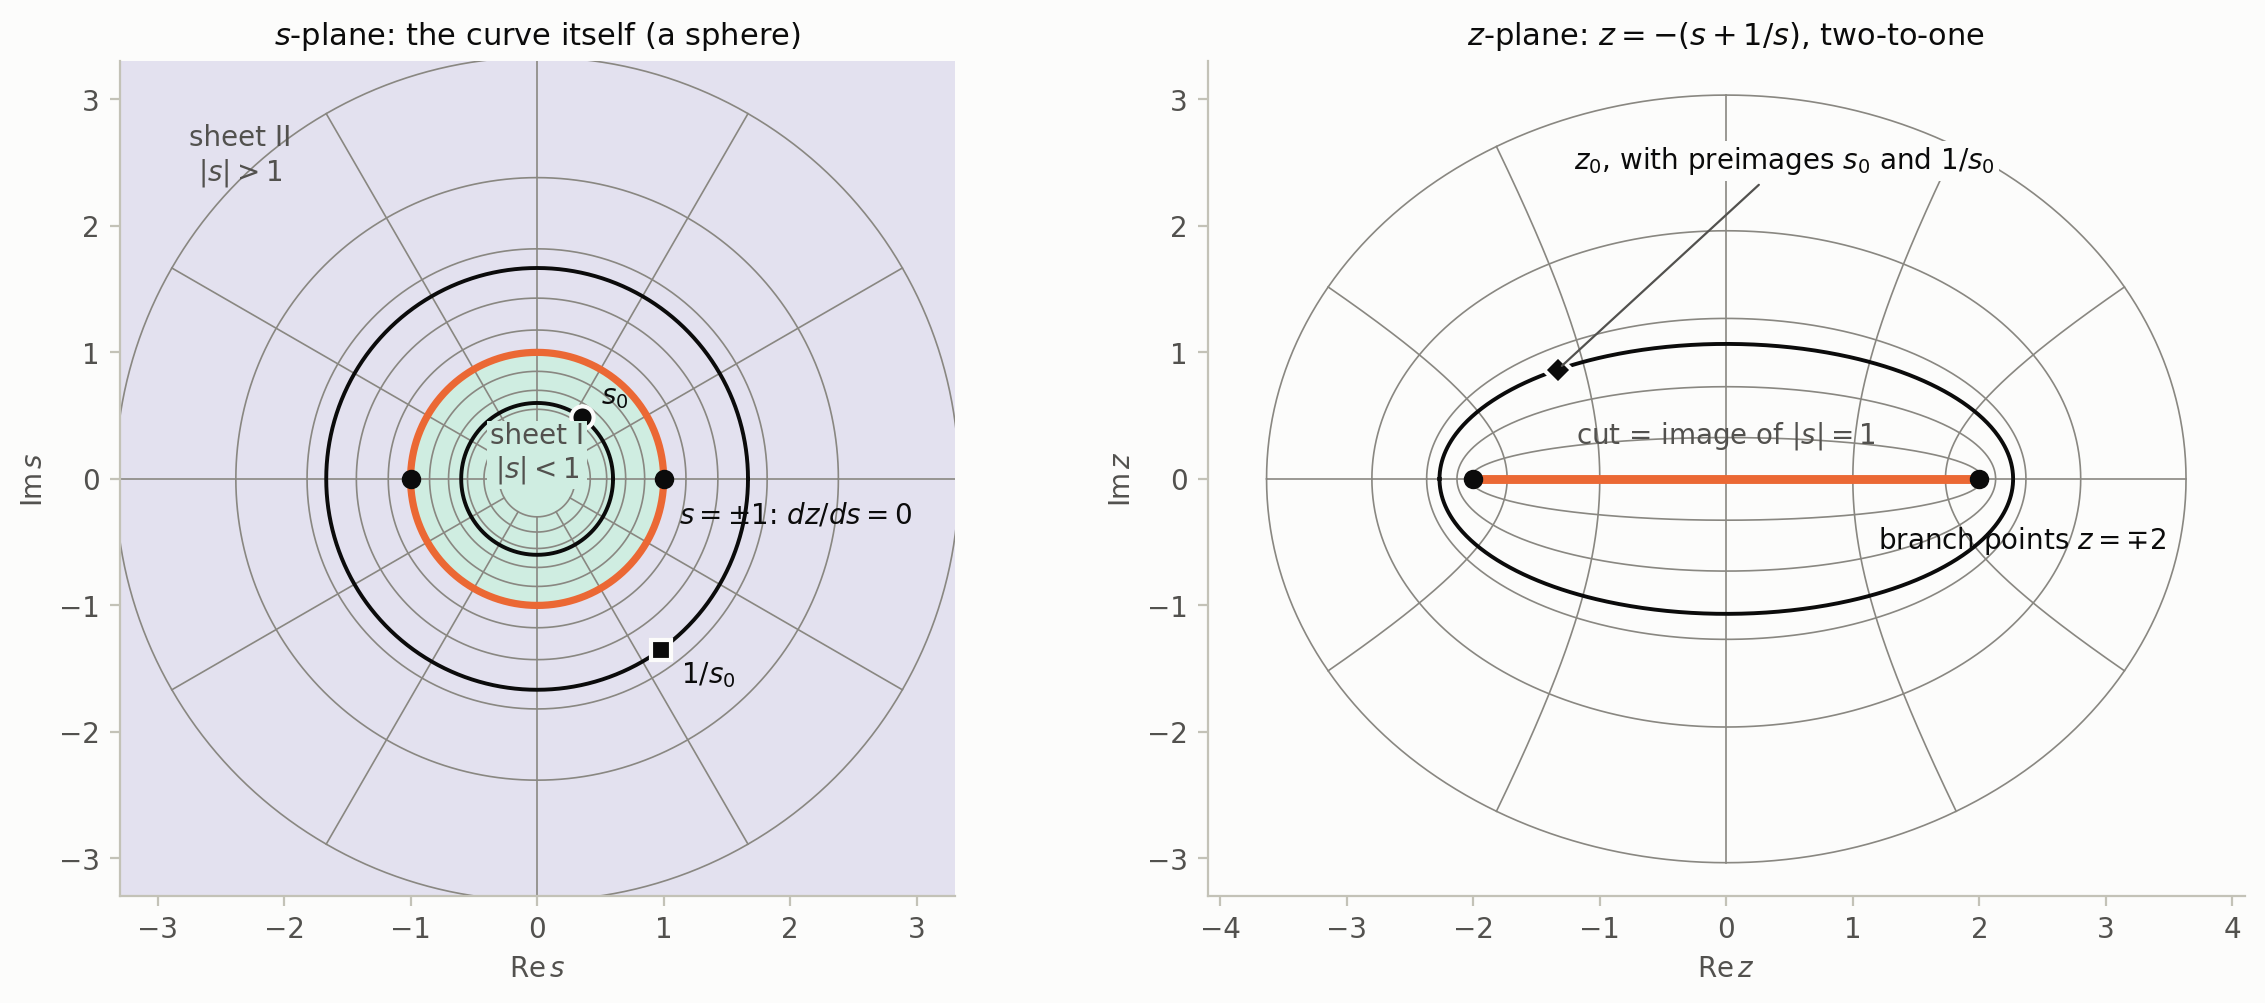

In [2]:
plot_sc.plot_joukowski();

**Figure 1.2: both sheets over the $z$-plane**, each drawn as the graph of $\operatorname{Im} s$.
- **Sheet I** (aqua) looks torn open along the cut: its upper edge rises to $+\sin\theta$ and its lower edge falls to $-\sin\theta$.
- **Sheet II** (violet, drawn only near the seam) closes the tear crosswise.
- **The seam** (orange) is where the two are glued. Over the cut it has height $\operatorname{Im} s = \pm\tfrac12\sqrt{4 - x^2} = \pm\pi\rho(x)$. **Seen from the side, the gluing seam is the semicircle law.**

Drag the figure to rotate it. Over $|x| > 2$ the sheets seem to cross, because both have $\operatorname{Im} s = 0$ there. That is an artifact of drawing a four-dimensional surface in 3D: the sheets are separated there in $\operatorname{Re} s$.

In [3]:
fig3d = plot_sc.semicircle_sheets_3d()
display(HTML(fig3d.to_html(include_plotlyjs="cdn", full_html=False)))   # fig3d.show() needs nbformat

**Figure 1.3: a cut is a condensate of poles.** For an $N \times N$ matrix, $S_N(z) = \frac1N \operatorname{tr}(M - z)^{-1} = -\frac1N \frac{p'(z)}{p(z)}$ is a rational function. It has a pole at every eigenvalue (filled dots) and a zero between each pair of neighbors (open dots: the roots of $p'$). As $N$ grows the poles fill $[-2, 2]$. Away from the real axis the phase portrait settles onto that of $s(z)$, in which the poles have merged into a cut. The finite-$N$ side is picked up again in §6.

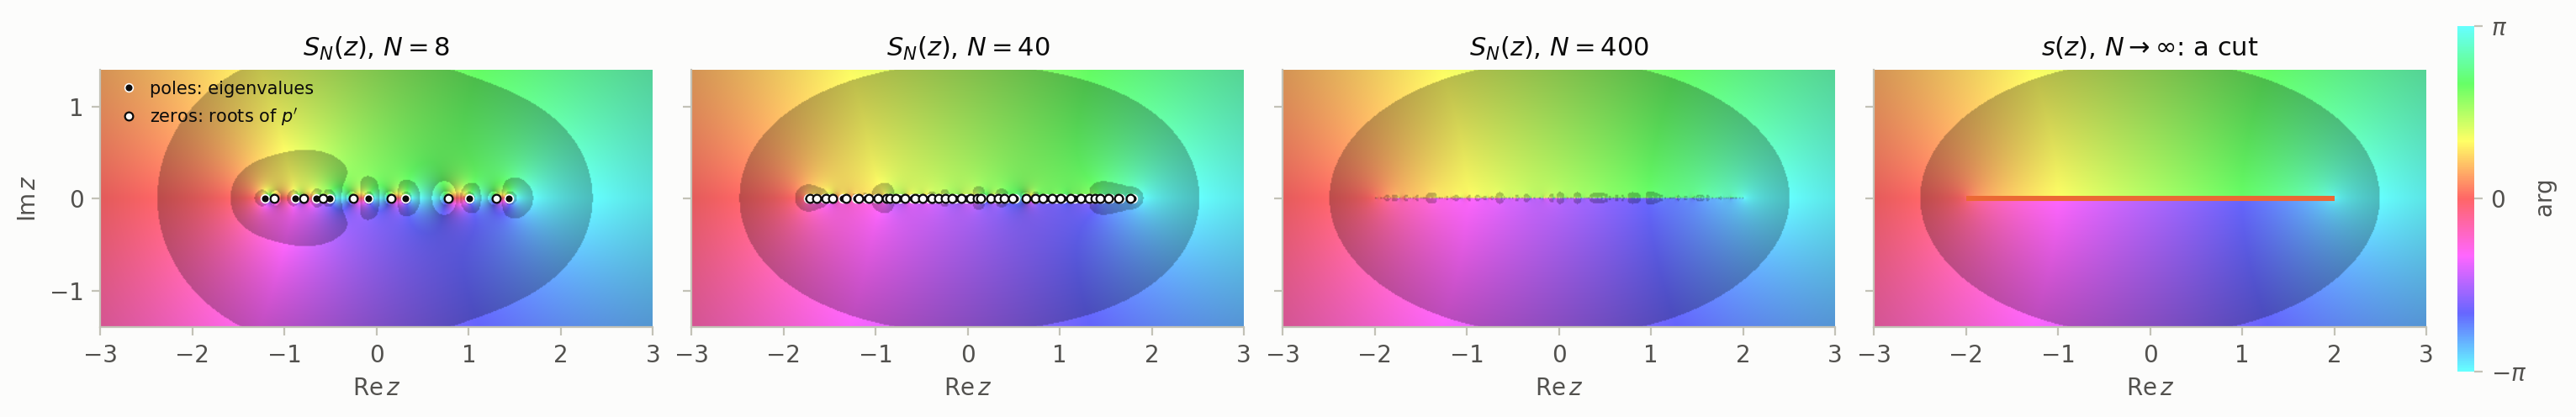

In [4]:
plot_sc.plot_poles_to_cut(rng=1);

**Figure 1.4: the density is the jump across the cut.**
- **Left (exact).** $\operatorname{Re} s$ is continuous across the cut, while $\operatorname{Im} s$ jumps from $-\pi\rho$ to $+\pi\rho$. So $s(x + i0) - s(x - i0) = 2\pi i\rho(x)$.
- **Right (one GOE matrix).** $\operatorname{Im} S_N(x + i\eta)/\pi$ is the eigenvalue histogram convolved with a Cauchy (Poisson) kernel of width $\eta$, so $\eta$ acts as a resolution. While $\eta$ is well above the spacing $\sim 1/N$ you see $\rho$. Once $\eta$ drops below the spacing you see the individual poles.

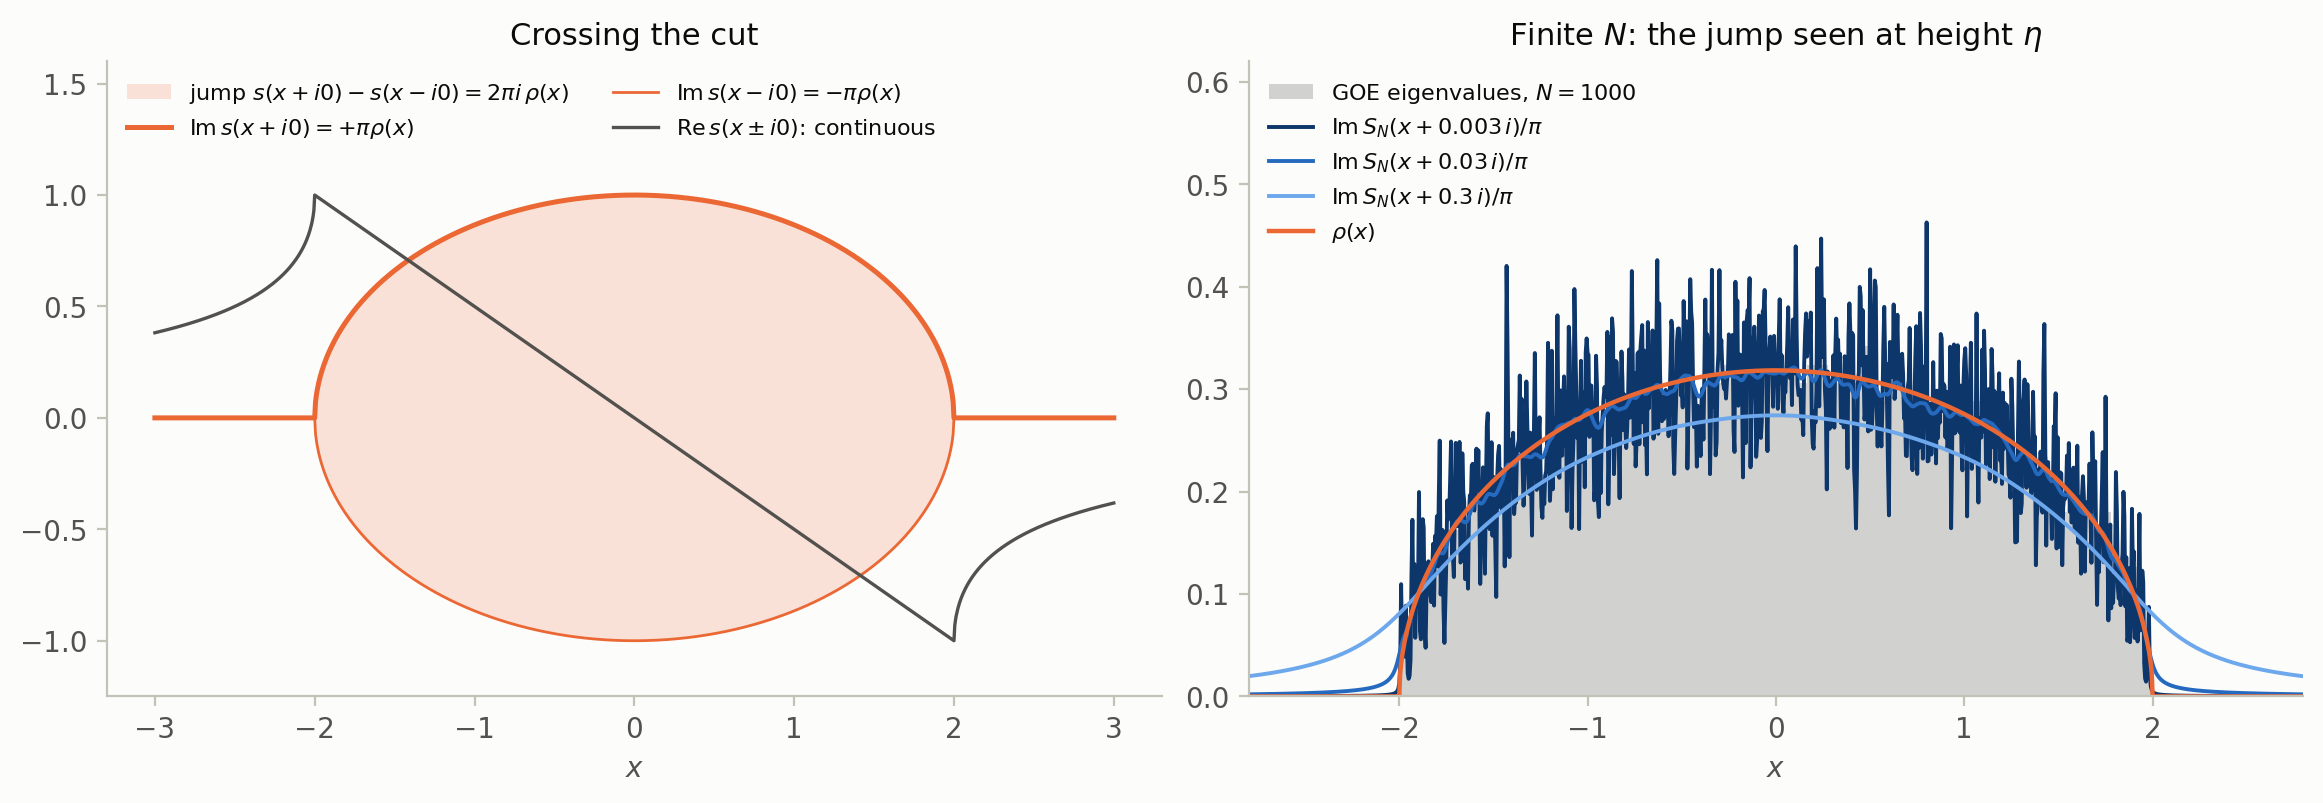

In [5]:
plot_sc.plot_density_jump(n=1000, rng=2);

## 2. Edges: square roots, Airy, Tracy–Widom

Put $y = z + 2s$. Then $y^2 = z^2 - 4$, which is the loop-equation form $y = V' - 2W$ of §3 with $V = x^2/2$.

**Figure 2.1, left: the curve.** The real points of this curve form a hyperbola over $|z| \ge 2$ (blue). Over the cut $y$ is imaginary, and the points $(z, \operatorname{Im} y)$ trace the circle $z^2 + (\operatorname{Im} y)^2 = 4$ (orange). The upper half of that circle is $2\pi\rho$: the semicircle law is literally a semicircle.

The hyperbola and the circle meet at $z = \pm 2$ with vertical tangents. Near there, both are the parabola $y^2 = 4(z - 2)$. Any smooth curve looks like this where it folds over the $z$-axis, which is why square-root edges are generic.

**Why the scale is $N^{-2/3}$.** Near the edge $\rho \approx \frac1\pi\sqrt{2 - x}$, so about $N\delta^{3/2}$ eigenvalues lie within $\delta$ of the edge. Setting that count to 1 gives $\delta \sim N^{-2/3}$. The exponent $\tfrac32$ comes from $\int y\,dx$ on $y^2 = x$.

**Right panel.** The same $\int y\,dx = \tfrac23|\xi|^{3/2}$ is the WKB phase of the Airy function. $\operatorname{Ai}$ is the wave whose classical curve is $y^2 = \xi$: it oscillates where $y$ is imaginary (inside the spectrum) and decays where $y$ is real.

**Middle panel.** GUE spectra zoomed into the variable $\xi = N^{2/3}(x - 2)$ converge to the Airy-kernel density $\operatorname{Ai}'^2 - \xi\operatorname{Ai}^2$. Deep inside the spectrum that density follows the square root $\sqrt{-\xi}/\pi$, and it smooths the square root out across the edge. The samples come from the Dumitriu–Edelman tridiagonal model, which makes $N = 800$ cheap.

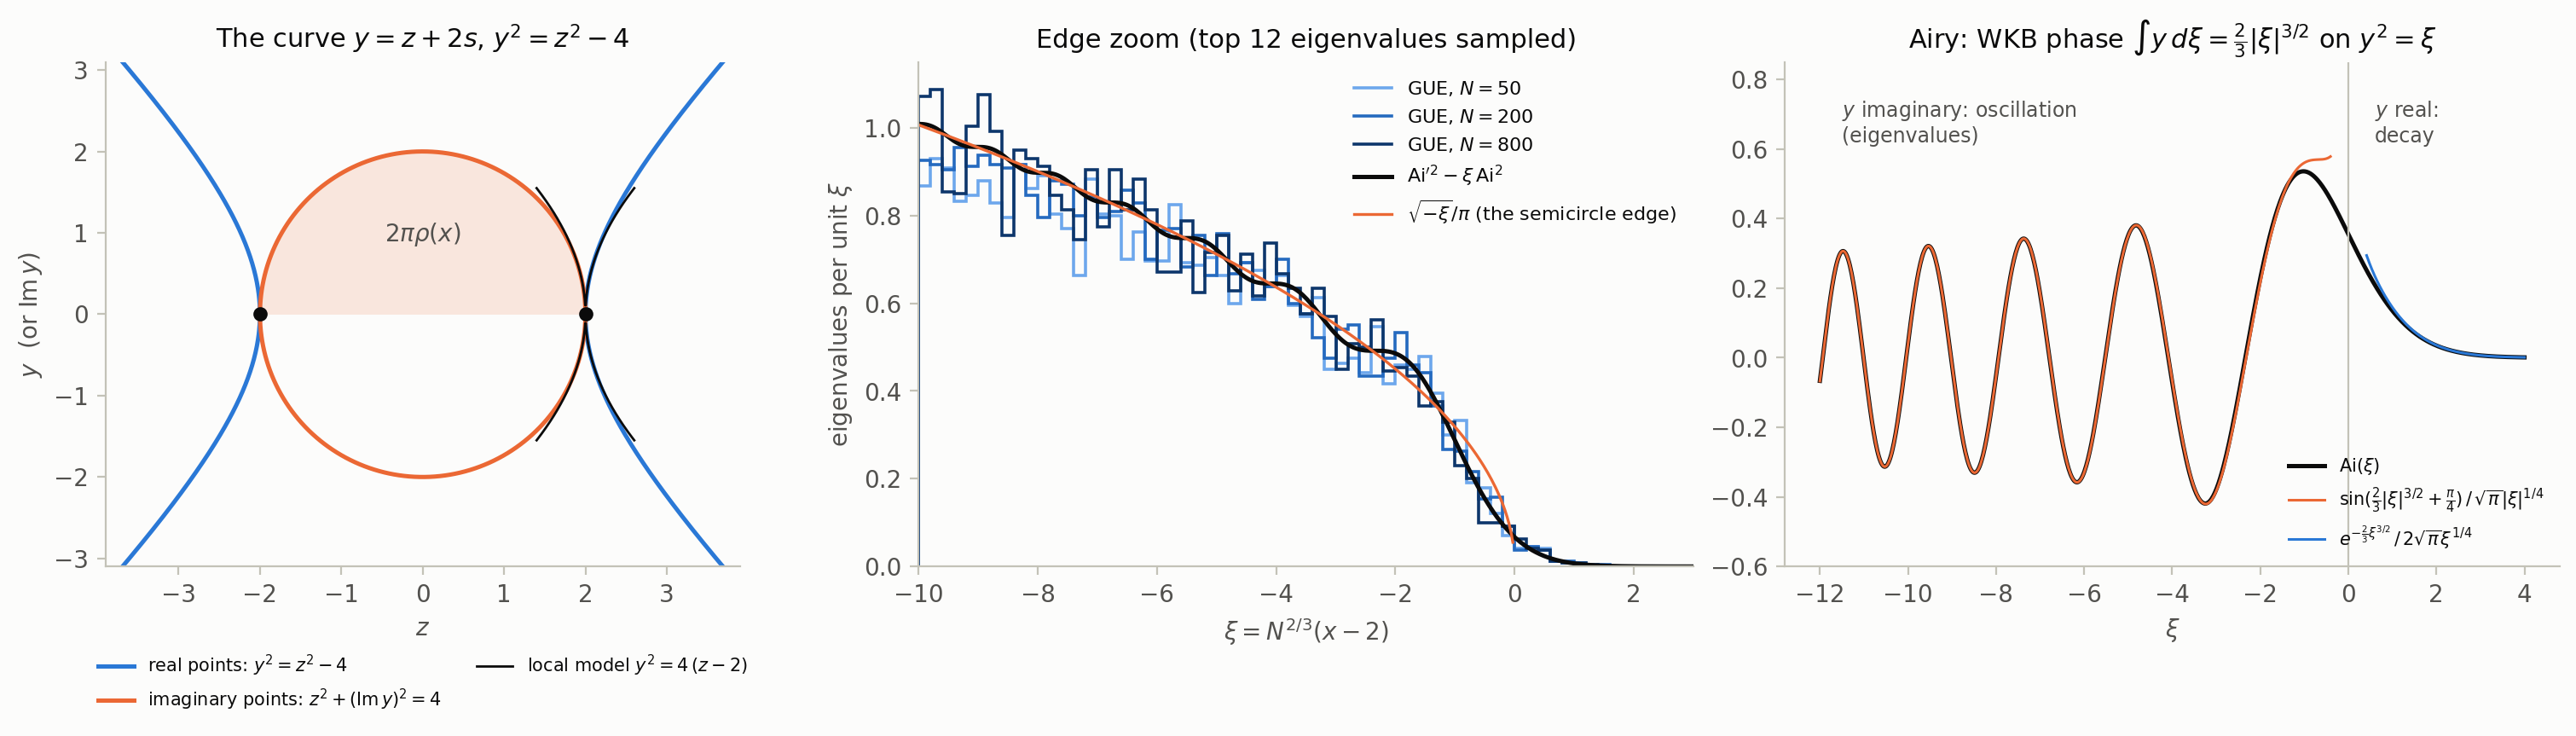

In [6]:
plot_sc.plot_edge(rng=3);

**Figure 2.2.** The largest eigenvalue fluctuates on the same $N^{-2/3}$ scale. Its limiting law is Tracy–Widom $F_1$ or $F_2$, depending on the symmetry class. The curves are computed as Fredholm determinants of the Airy kernel, using Bornemann's quadrature.

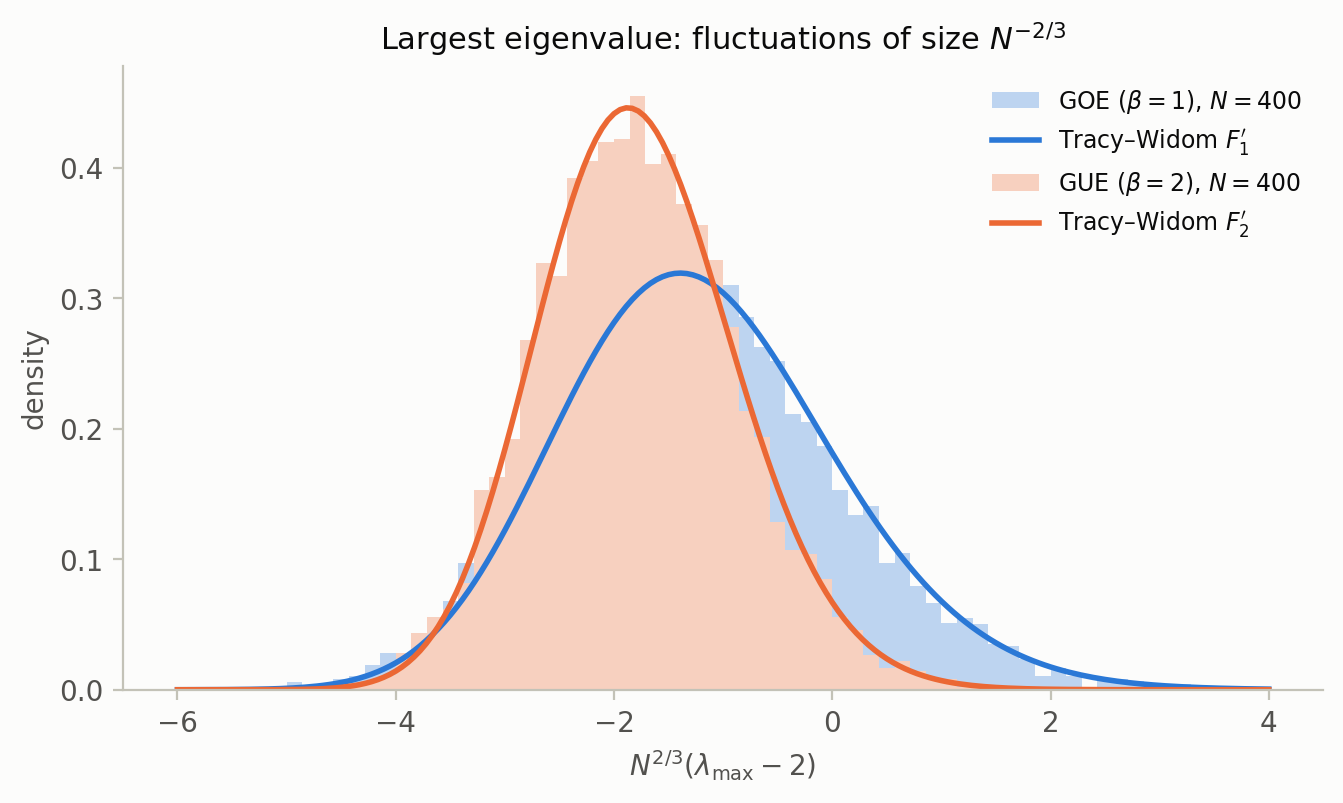

In [7]:
plot_sc.plot_tracy_widom(rng=4);

## 3. Genus and the shape of the support

The models are $e^{-N\operatorname{tr}V(M)}$ with $V(x) = \frac g4 x^4 + \frac a2 x^2 + tx$. For each one, `sc.spectral_curve` finds the equilibrium curve $y^2 = V'^2 - 4P = M(x)^2\prod_i(x - e_i)$ in two steps:
1. It first tries one cut, by solving the endpoint equations.
2. If that solution is not admissible, it looks for two cuts. There the double root $d$ of $F$ fixes $P$, and $d$ is chosen so that the B-period vanishes.

The histograms come from Metropolis sampling of the eigenvalue log-gas at $N = 100$, which is independent of the curve computation.

**$k$ cuts give genus $k - 1$** by Riemann–Hurwitz. The curve is a 2-sheeted cover of the sphere branched at the $2k$ edges, so $\chi = 2 \cdot 2 - 2k = 2 - 2g$, which gives $g = k - 1$.

**Figure 3.1: force balance.** $V_{\rm eff}(x) = V(x) - 2\int\log|x - \lambda|\,\rho(\lambda)\,d\lambda$ is the potential a single eigenvalue feels: the external well plus the repulsion from all the others.
- **On the support** $V_{\rm eff}$ is exactly flat: no net force acts where the eigenvalues sit.
- **Off the support** $V_{\rm eff}' = y$. That is why $y$ is real off the cuts and imaginary on them.
- **The split.** Deepening the double well drives the density at 0 to zero at $a = -2$ (with $g = 1$). Beyond that, a barrier appears in $V_{\rm eff}$ and the support splits in two.

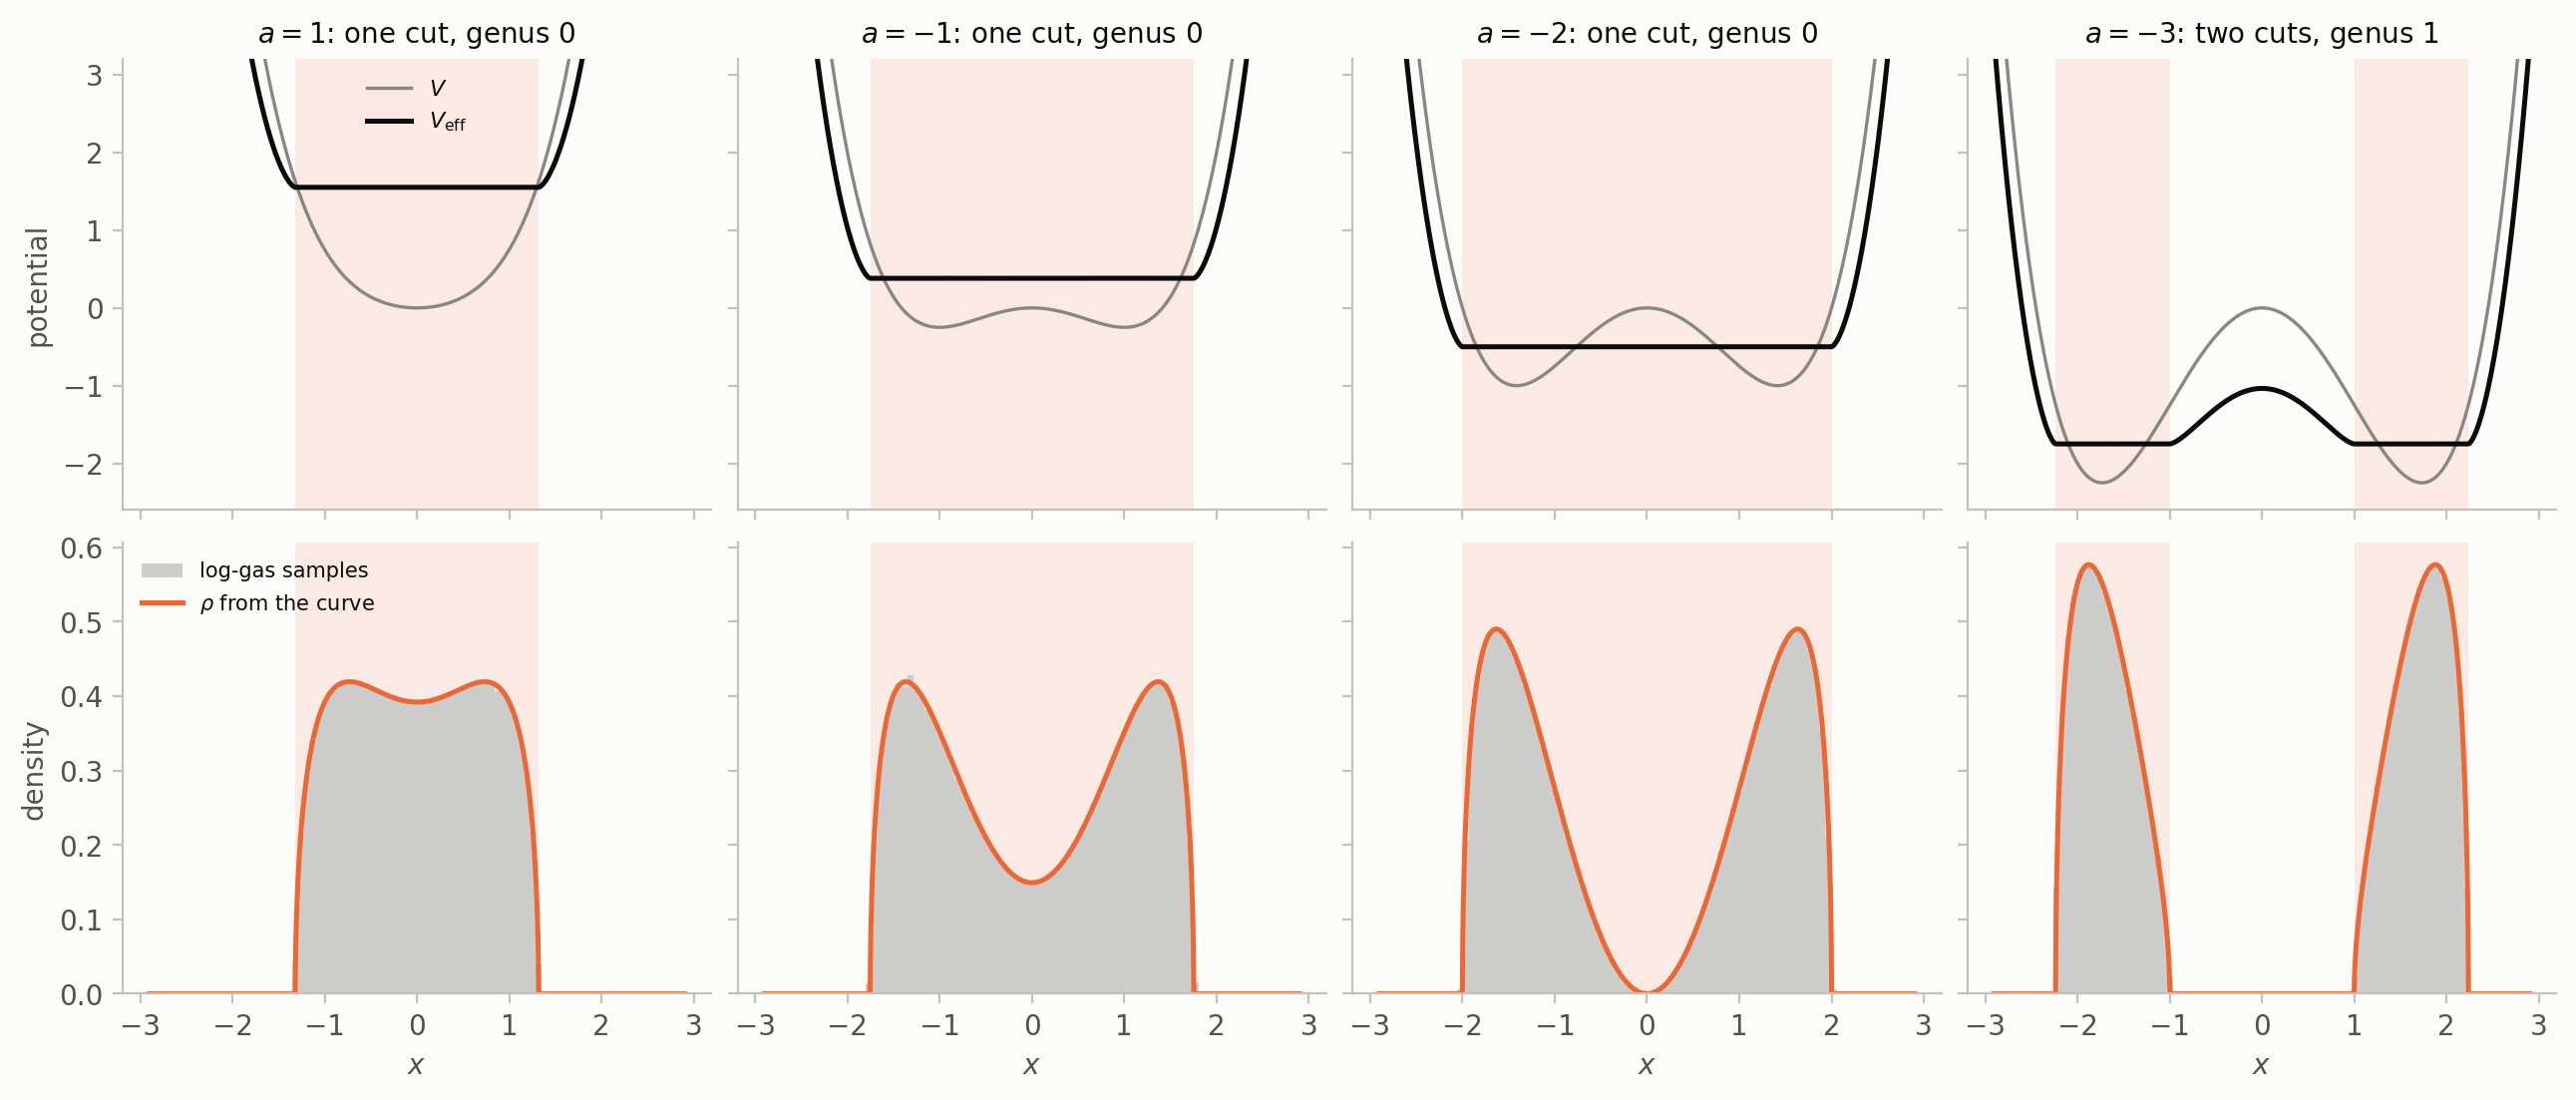

In [8]:
models = [sc.QuarticModel(g=1, a=a) for a in (1.0, -1.0, -2.0, -3.0)]
curves = [sc.spectral_curve(m) for m in models]
samples = [sc.sample_log_gas(c.model.V, 100, window=(c.edges[0] - 0.6, c.edges[-1] + 0.6), rng=rng)[0]
           for c in curves]
sc.plot_cut_transition(curves, samples);

**Figure 3.2: how the genus jumps.** Over the complex $x$-plane, $F = V'^2 - 4P$ has degree 6.
- **Branch points** are its simple roots.
- **Nodes** are its double roots, the zeros of $M$, where the curve crosses itself. Each node lowers the genus by one from the value 2 that $y^2 = (\text{degree } 6)$ would otherwise have.
- **One-cut phase.** There are two complex nodes, so the genus is $2 - 2 = 0$.
- **The collision.** As $a$ decreases, the two nodes slide down the imaginary axis and collide on the support at $a = -2$. They come out as one real node plus two new branch points, so the genus becomes $2 - 1 = 1$.

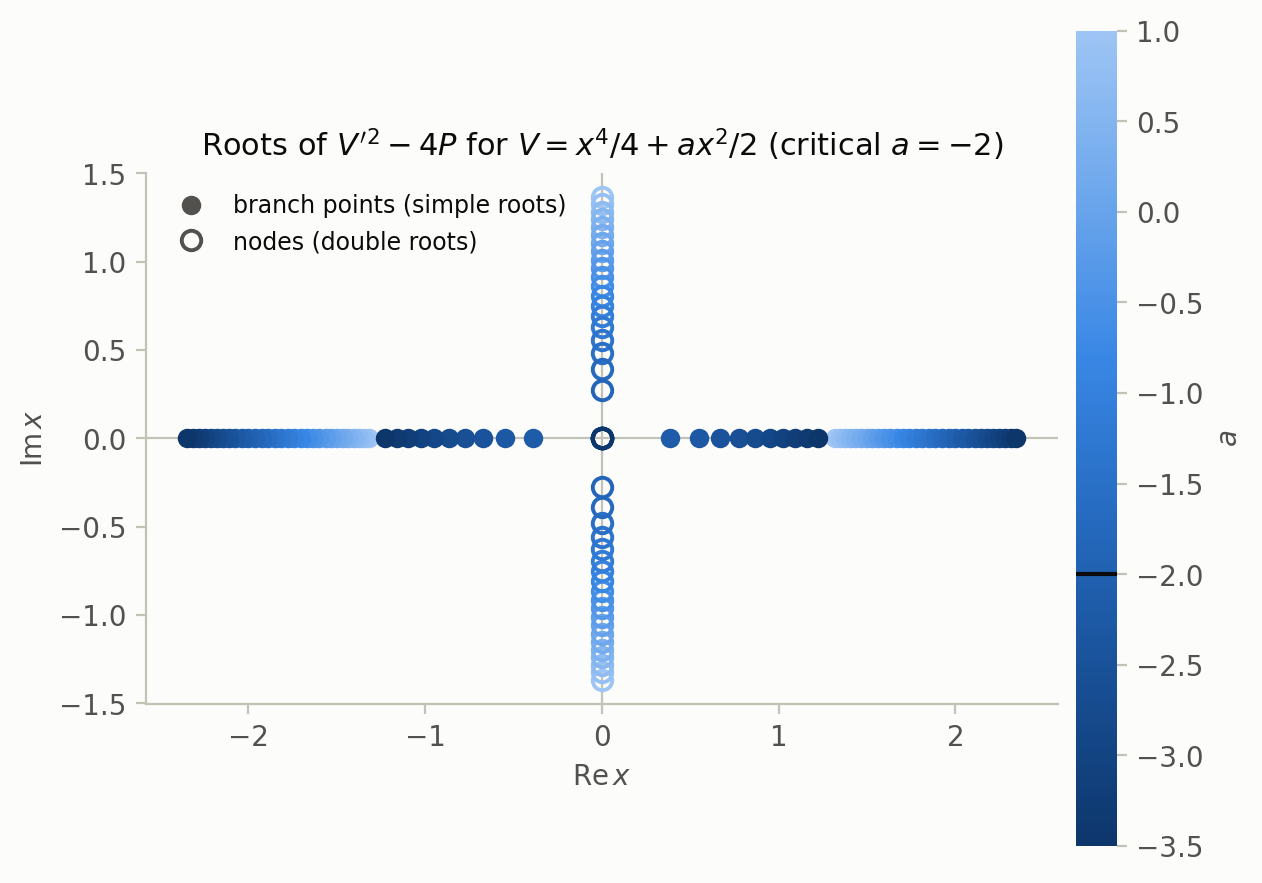

In [9]:
plot_sc.plot_branch_points(onp.linspace(1.0, -3.5, 31));

**Figure 3.3: periods, seen in the real plane.** A tilted double well ($t = 0.25$) makes the two intervals unequal, so the filling fractions are not forced to be $\frac12$.
- **Left: the real section of $y^2 = F$.** Over each cut, the points $y = \pm 2\pi i\rho$ form an oval: the real shadow of an A-cycle. Its area is $\int 4\pi\rho = 4\pi\epsilon_i$, which is $\oint_{A_i} y\,dx$ up to a constant.
- **The gap.** There the real curve pinches at the node $d$. Equilibrium means $V_{\rm eff}$ takes the same value on both cuts, which is $\int_{\rm gap} y\,dx = 0$. That makes the two lobes equal in area, a Maxwell equal-area construction, and it is the statement that the B-period vanishes.
- **Right.** The same periods as contour integrals in the complex plane: $\epsilon_i = -\frac1{4\pi i}\oint_{A_i} y\,dx$. They are compared with the direct integral of $\rho$ and with eigenvalue counts from the log-gas.

cuts: [[-2.2898, -0.9728], [1.0338, 2.1773]]   filling fractions: [0.58413 0.41587]


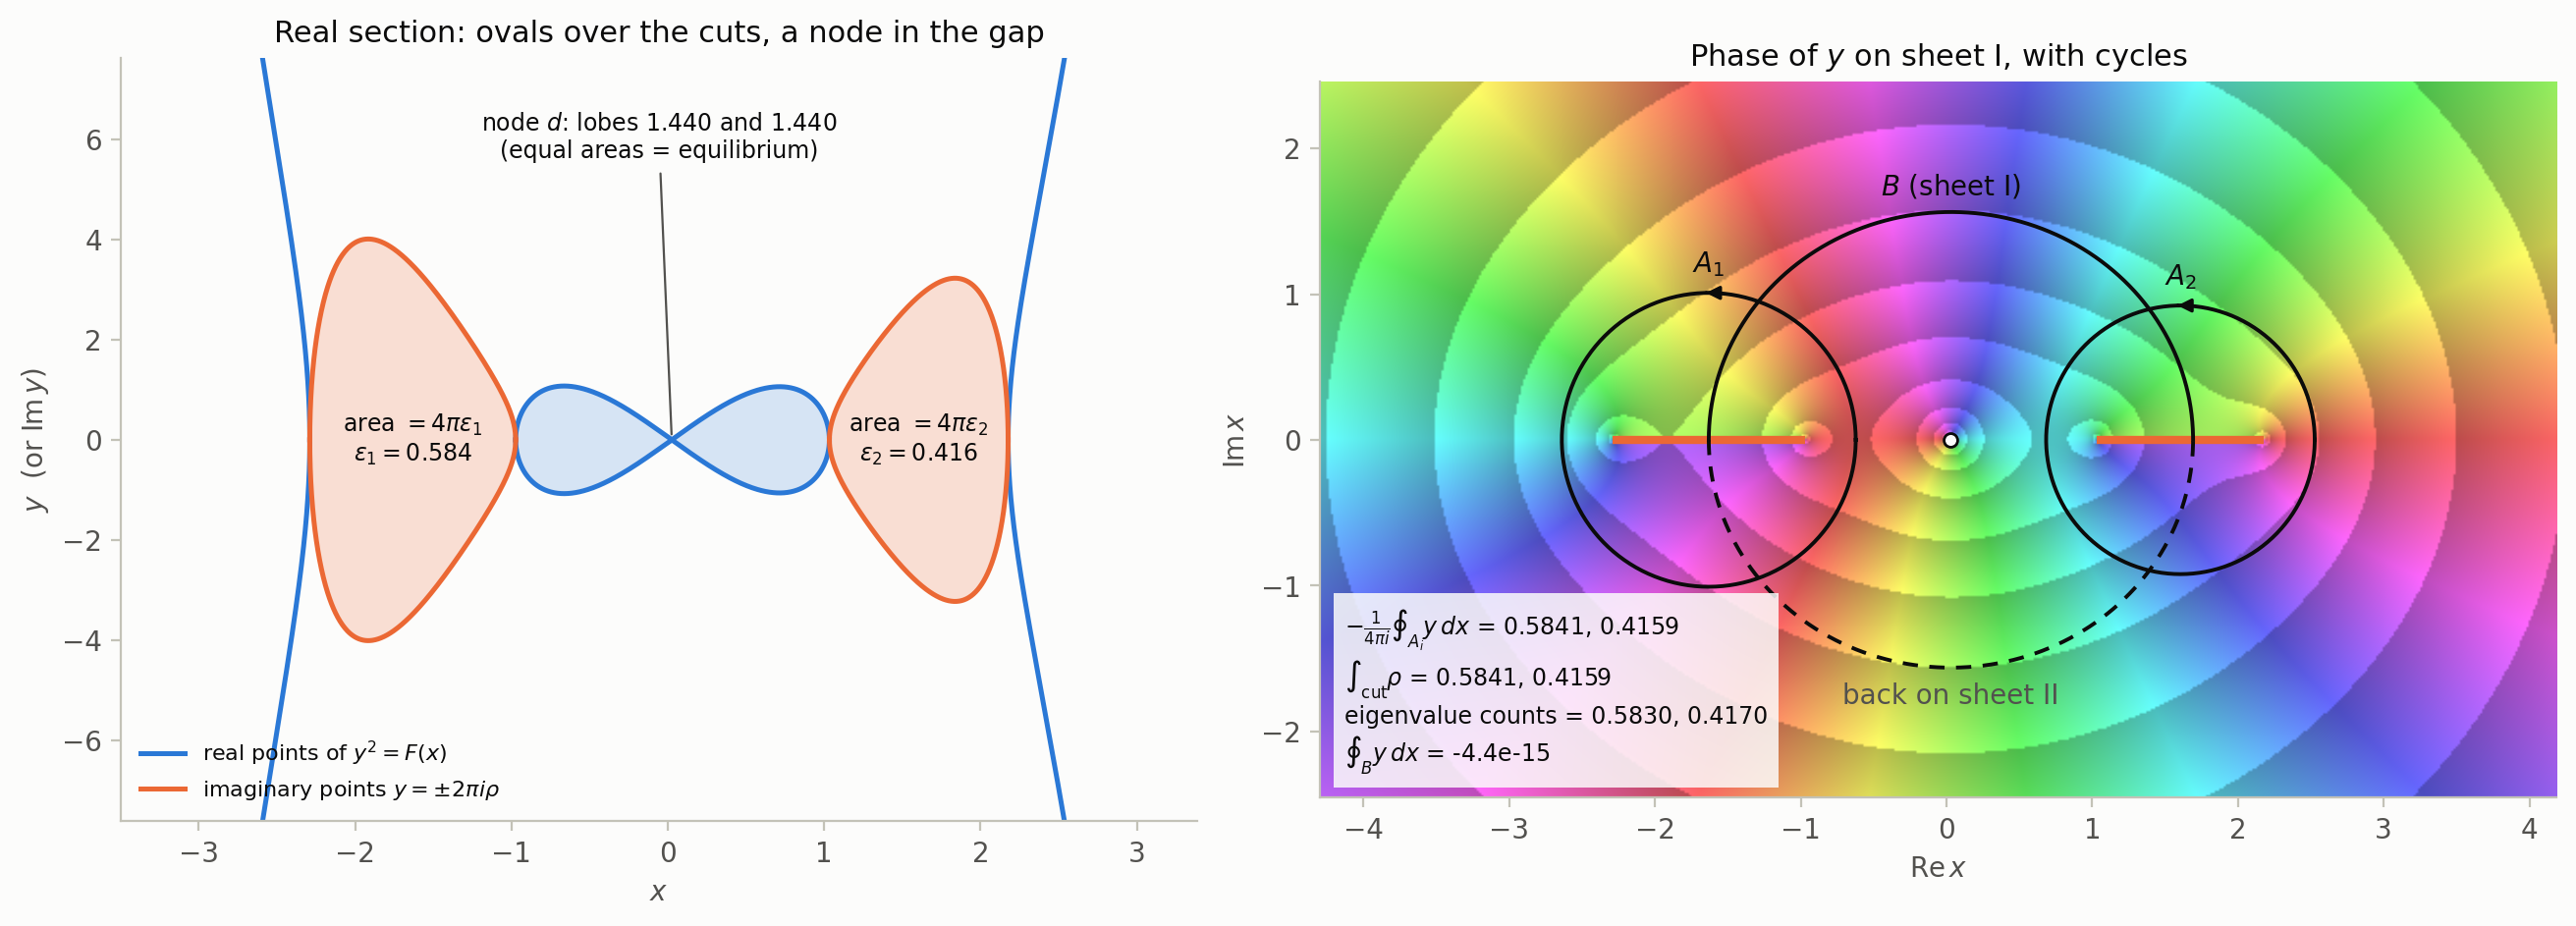

In [10]:
tilted = sc.spectral_curve(sc.QuarticModel(g=1, a=-3.0, t=0.25))
lam = sc.sample_log_gas(tilted.model.V, 100, window=(tilted.edges[0] - 0.6, tilted.edges[-1] + 0.6), rng=rng)[0]
sc.plot_real_section(tilted, lam);
print("cuts:", onp.round(tilted.cuts, 4).tolist(), "  filling fractions:", onp.round(tilted.filling_fractions(), 5))

**Figure 3.4: sheet I is a disk or a cylinder, and the curve is its double.**
- **Top row: one cut.** The Joukowski coordinate $s$ maps sheet I (the plane minus $[-2, 2]$) onto a disk. The ellipses and hyperbolas are that disk's polar grid. Gluing two disks along their boundary circle (the cut) gives a sphere.
- **Bottom row: two cuts.** The Abel map $u = \int dx/\tilde y$, with $\tilde y^2 = \prod(x - e_i)$, sends sheet I onto the rectangle $[-K_B, 0] \times [-K_A, K_A]$. Its top and bottom edges are both the gap, so they are glued, and sheet I is a cylinder (equivalently an annulus) whose two boundary circles are the cuts. Sheet II is the mirror rectangle. Gluing the two cylinders along both circles gives the period rectangle of a torus.
- **Reading the torus.** The $x$-plane coordinate lines are the same lines in every panel of the row. Closed curves around a cut are A-cycles, and they become meridians of the torus. Curves running from cut to cut are halves of B-cycles, and they become longitudes. The blue real ovals (the gap, and the real line through $\infty$) become the inner and outer equators, and the orange cuts become the two seams.

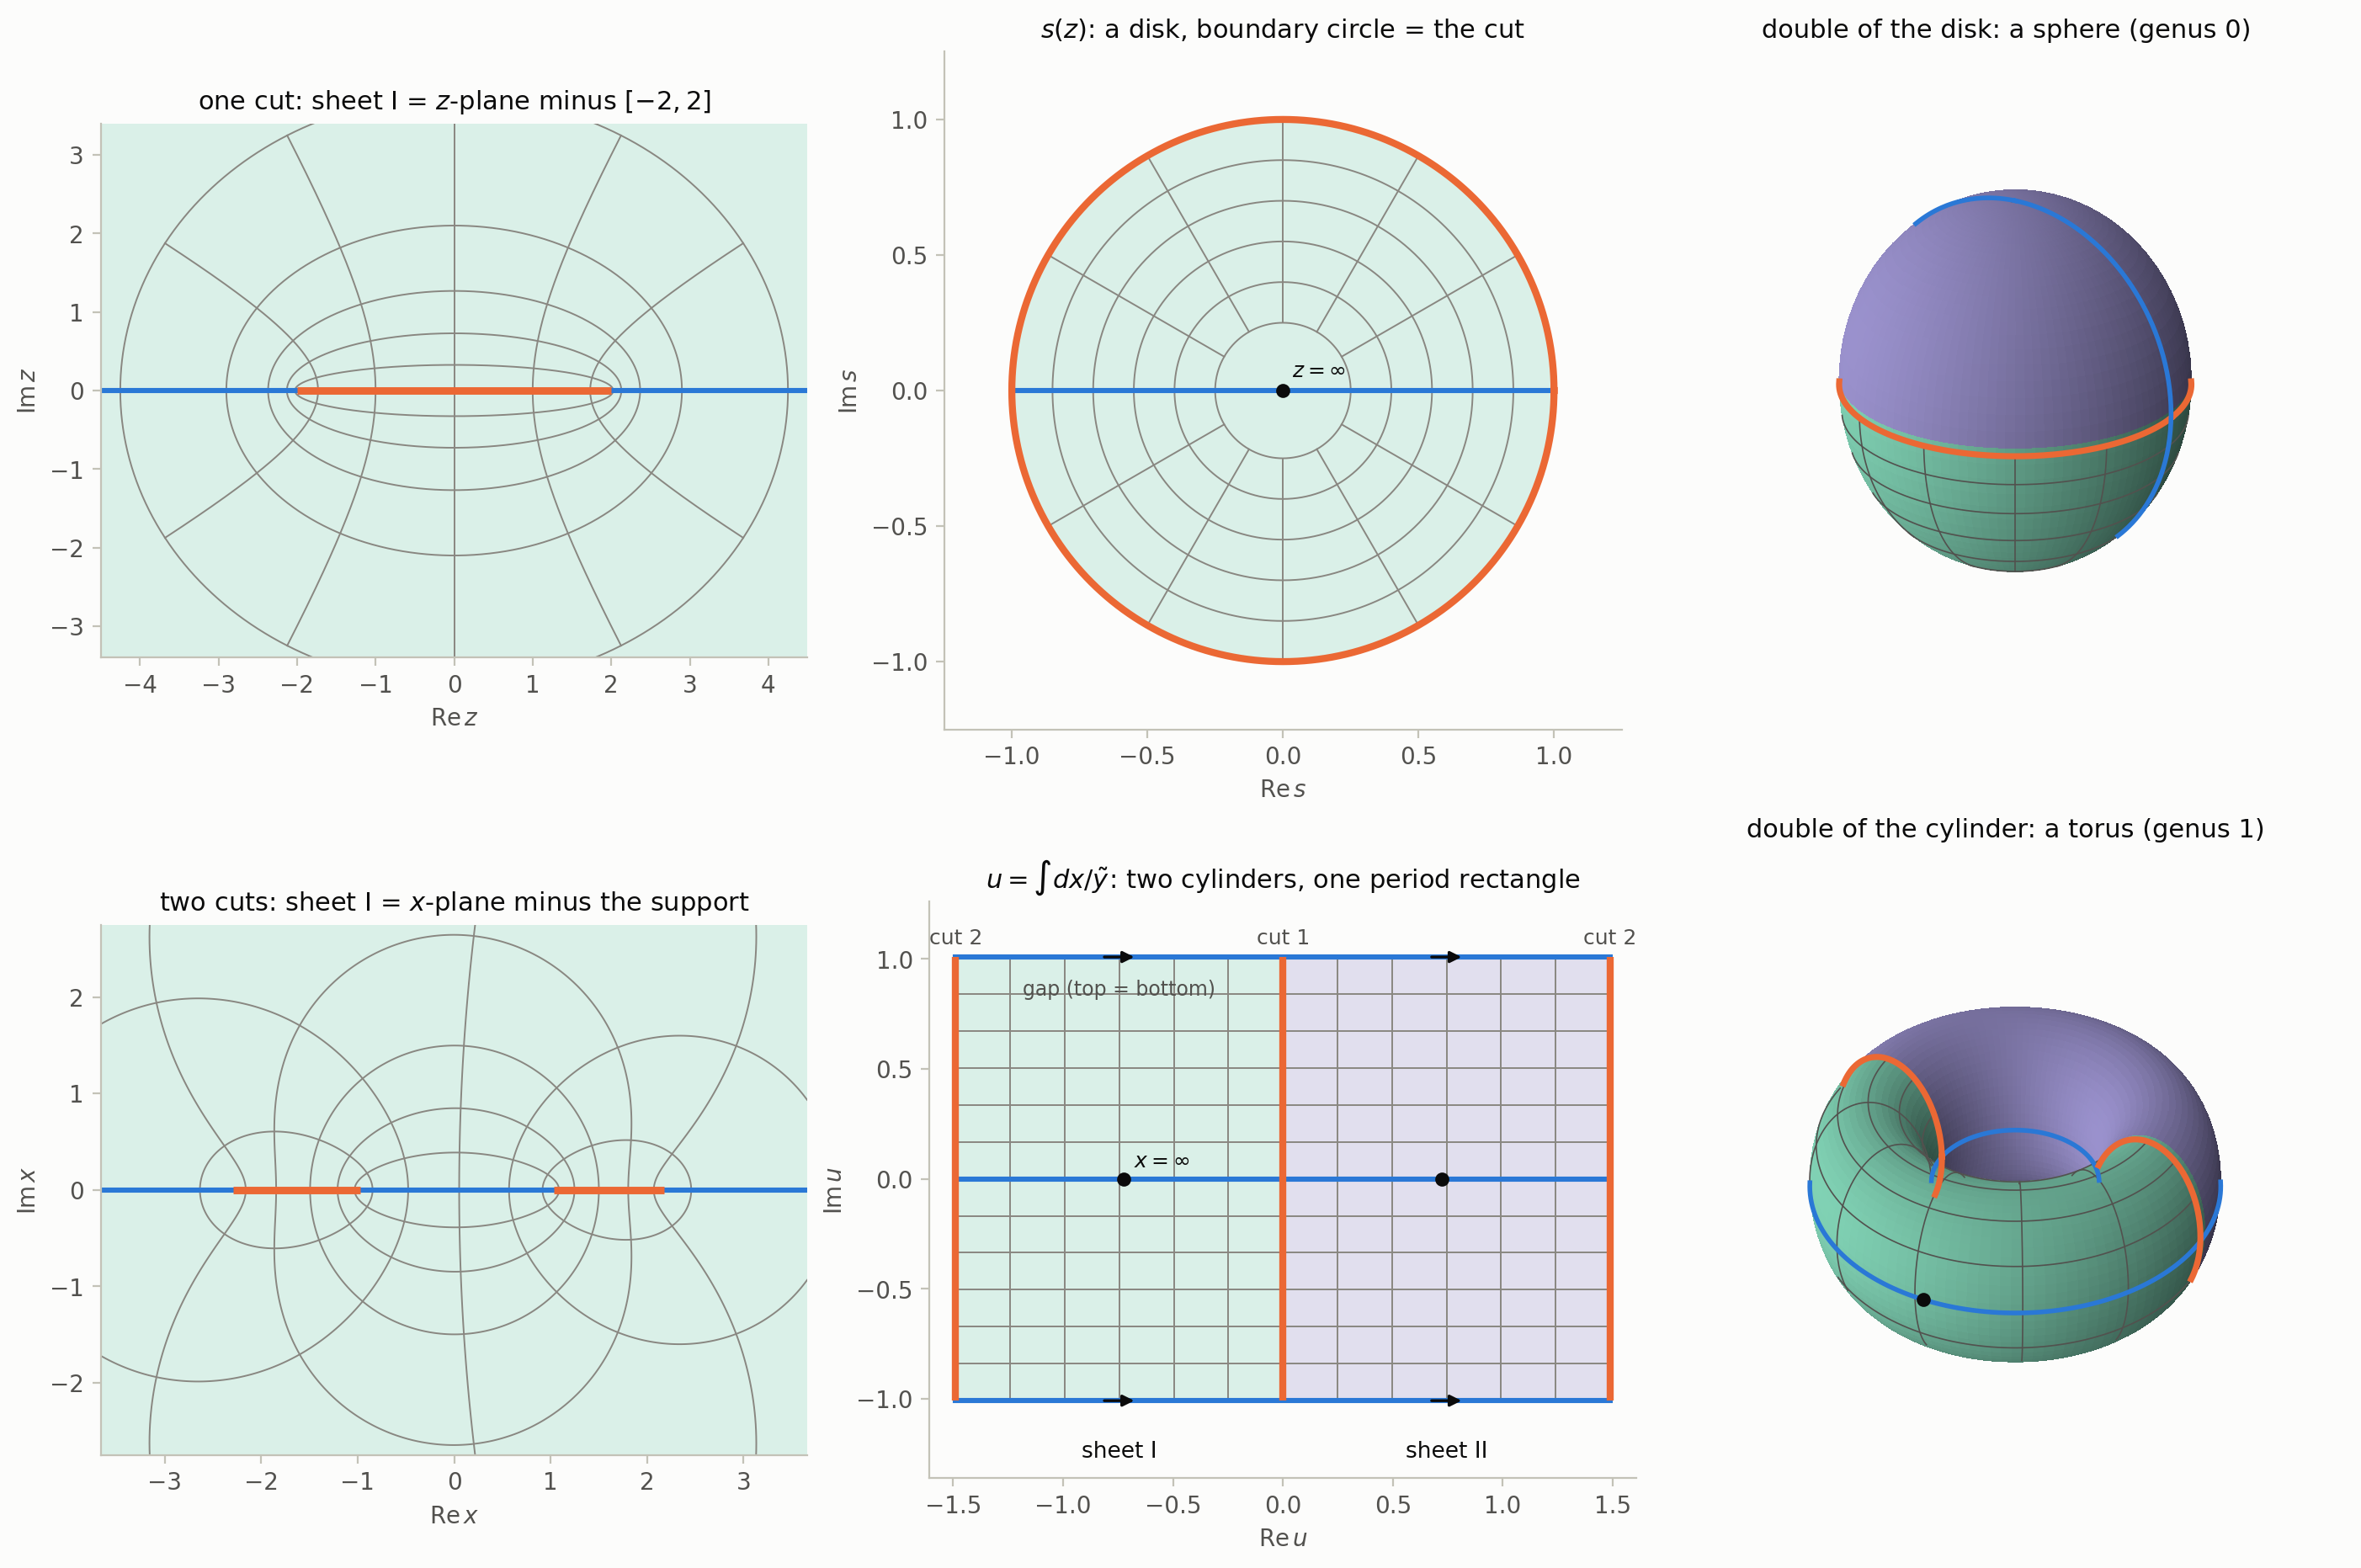

In [11]:
plot_sc.plot_uniformization(tilted);

## 4. Free probability as elimination

The polynomial method is short enough to write out in full:
1. **Invert.** Swapping the coordinates of $L(G, z) = 0$ gives the inverse function $K = G^{-1}$, and $R(w) = K(w) - 1/w$. So the substitution $G \to w$, $z \to r + 1/w$ turns the curve of $G$ into the curve of $R$.
2. **Add.** R-transforms add under free convolution, and a resultant eliminates the auxiliary variable $u$.
3. **Undo the substitution** to get back a curve for $G$.

The worked example is Bernoulli ⊞ Bernoulli, i.e. the matrix $\pm1$ plus a randomly rotated $\pm1$.

In [12]:
G, z, w, r = sc.G, sc.Z, sc.W, sc.R
u, a = sp.symbols("u a", positive=True)
bern = sc.bernoulli_poly(1)
res = sp.factor(sp.resultant(sc.r_curve(bern).subs(r, r - u), sc.r_curve(bern).subs(r, u), u))
display(Markdown(
  f"Bernoulli: ${sp.latex(sp.Eq(bern, 0))}$, whose $R$-curve is ${sp.latex(sp.Eq(sc.r_curve(bern), 0))}$  \n"
  f"resultant in $u$: ${sp.latex(sp.Eq(res, 0))}$  \n"
  f"back in $(G, z)$: ${sp.latex(sp.Eq(sp.factor(sc.g_curve(res)), 0))}$  \n"
  f"physical factor: ${sp.latex(sp.Eq(sp.factor(sc.free_sum(bern, bern)), 0))}$, "
  r"i.e. $G = 1/\sqrt{z^2 - 4}$: the arcsine law"))
cubic = sc.g_curve(sp.resultant(sc.r_curve(sc.semicircle_poly()).subs(r, r - u), sc.r_curve(sc.bernoulli_poly(a)).subs(r, u), u))
display(Markdown(f"semicircle ⊞ Bernoulli($\\pm a$): ${sp.latex(sp.Eq(sp.collect(sp.expand(cubic), G), 0))}$"))

Bernoulli: $G \left(z^{2} - 1\right) - z = 0$, whose $R$-curve is $r^{2} w + r - w = 0$  
resultant in $u$: $w \left(r w + 1\right)^{2} \left(r^{2} w + 2 r - 4 w\right) = 0$  
back in $(G, z)$: $z^{2} \left(G^{2} z^{2} - 4 G^{2} - 1\right) = 0$  
physical factor: $G^{2} z^{2} - 4 G^{2} - 1 = 0$, i.e. $G = 1/\sqrt{z^2 - 4}$: the arcsine law

semicircle ⊞ Bernoulli($\pm a$): $G^{3} - 2 G^{2} z + G \left(- a^{2} + z^{2} + 1\right) - z = 0$

**Figure 4.1: swap the coordinates, then add.**
- **Left.** Each bold curve is $G$ on the real axis away from the support. It sits on the real locus of its curve, drawn thin.
- **Middle.** Reflecting in the diagonal gives the inverse function $K$. Nothing new is computed: it is the same curve, read from the other axis.
- **Right.** Subtracting $1/w$ gives $R$. The semicircle's $R(w) = w$ is a straight line. The free sum's $R$, taken from the resultant curve, coincides with the pointwise sum $R_{\rm sc} + R_{\rm B}$ (dots).

free-sum curve for $a = 1.4$: $25 G^{3} - 50 G^{2} z + 25 G z^{2} - 24 G - 25 z = 0$

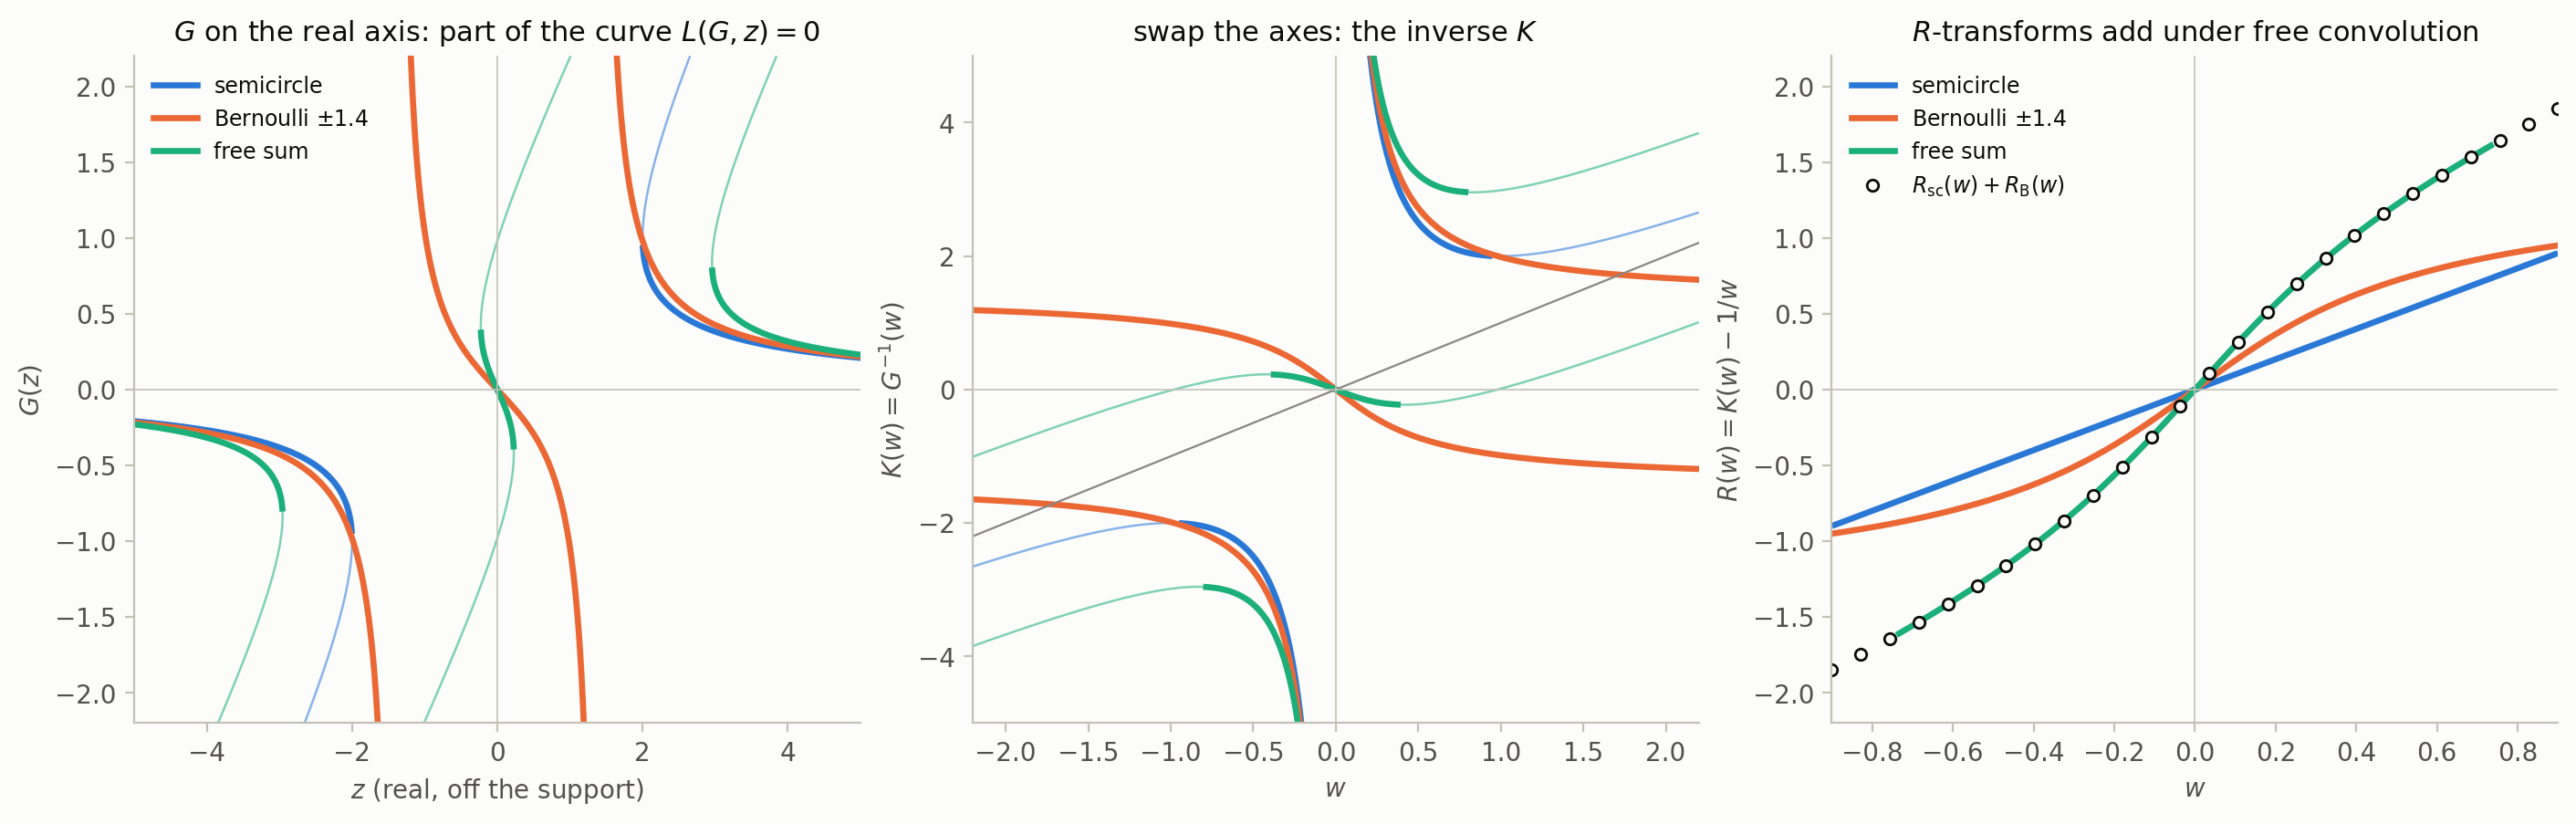

In [13]:
fig, L = plot_sc.plot_r_transform(a=1.4)
display(Markdown(f"free-sum curve for $a = 1.4$: ${sp.latex(sp.Eq(sp.factor(L), 0))}$"))

**Figure 4.2: free convolution is what adding randomly rotated matrices does.** A GOE matrix $W$ is rotation invariant, so $W + A$ is asymptotically in free position with $A$. Here $A$ has eigenvalues $\pm a$.
- **The split.** As the atoms move apart, the support of the sum splits at $a = 1$. From the cubic, $\rho(0) = \sqrt{1 - a^2}/\pi$.
- **The genus can rise.** For $a > 1$ the curve of the sum has genus 1, although both summands have genus 0.

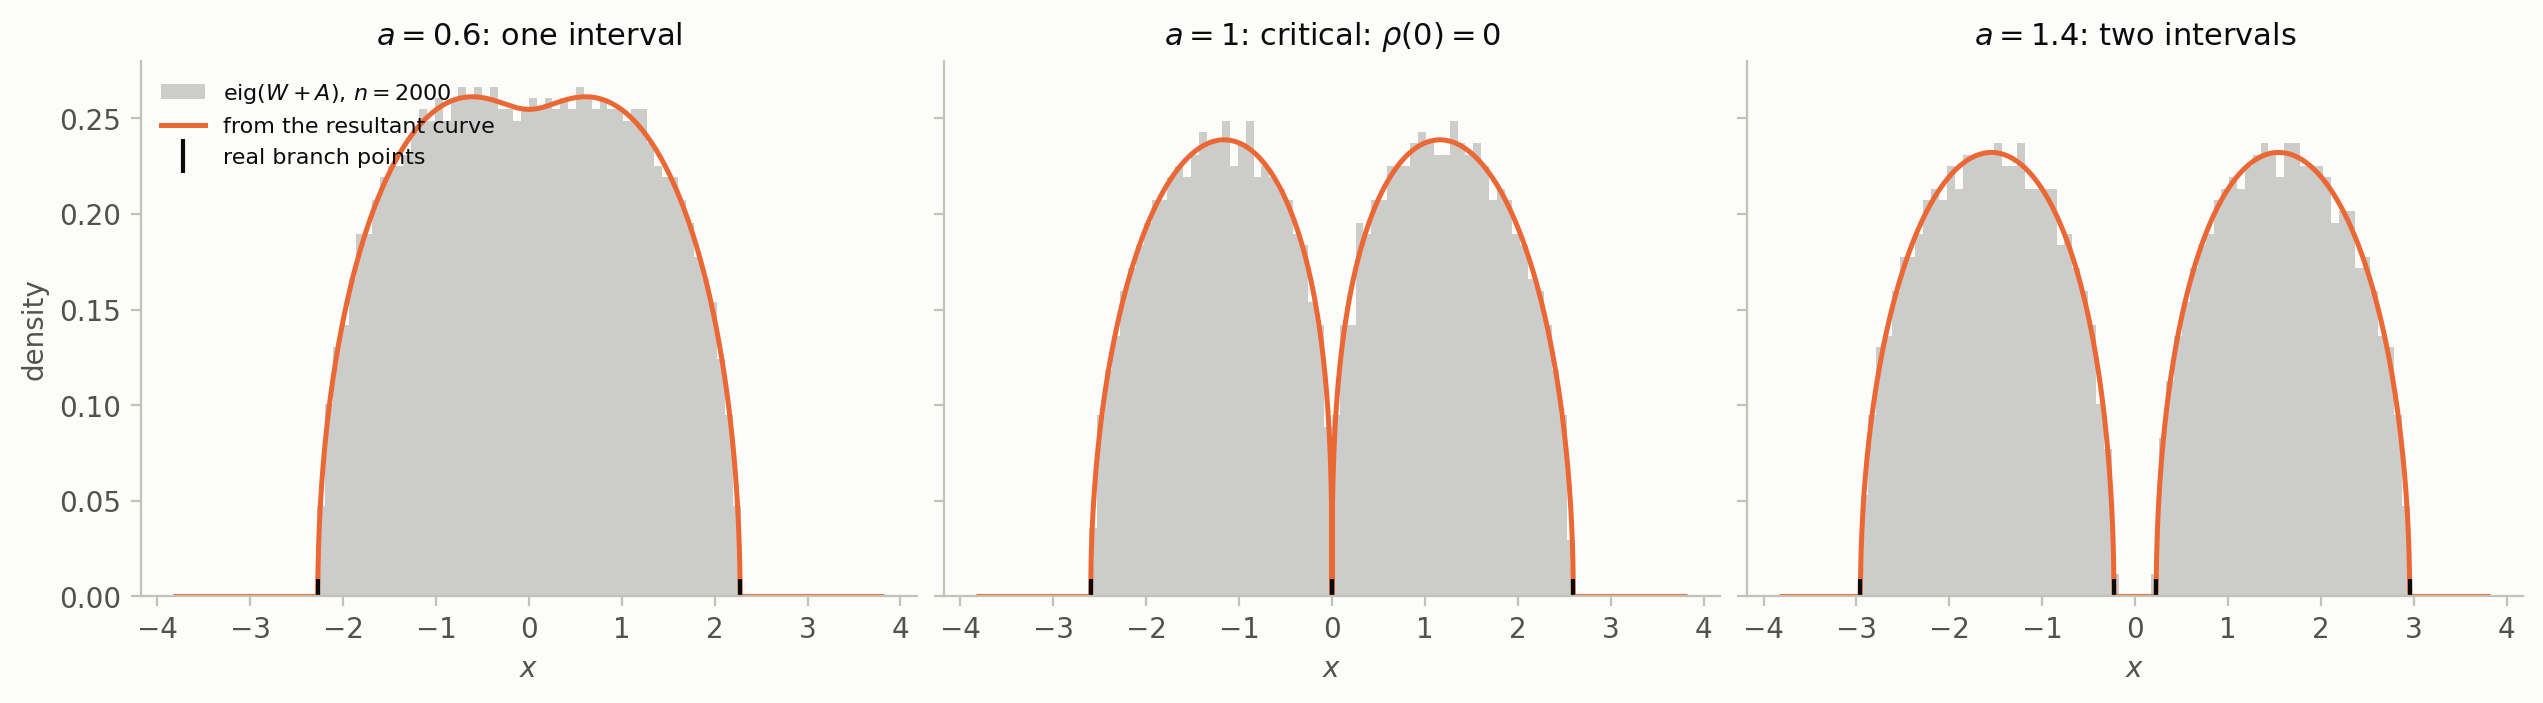

In [14]:
plot_sc.plot_free_sums((0.6, 1.0, 1.4), n=2000, rng=rng);

## 5. Maps, the genus expansion, and topological recursion

**Figure 5.1: gluing polygons.** Glue the sides of a $2k$-gon in pairs, orientably. The surface you get has one face and $k$ edges. Its vertices are the cycles of $i \mapsto \sigma(i) + 1$, so Euler's formula gives its genus.

A chord diagram draws each glued pair as a chord. The non-crossing diagrams give spheres, and there are Catalan$(k)$ of them. Any crossing forces a handle.

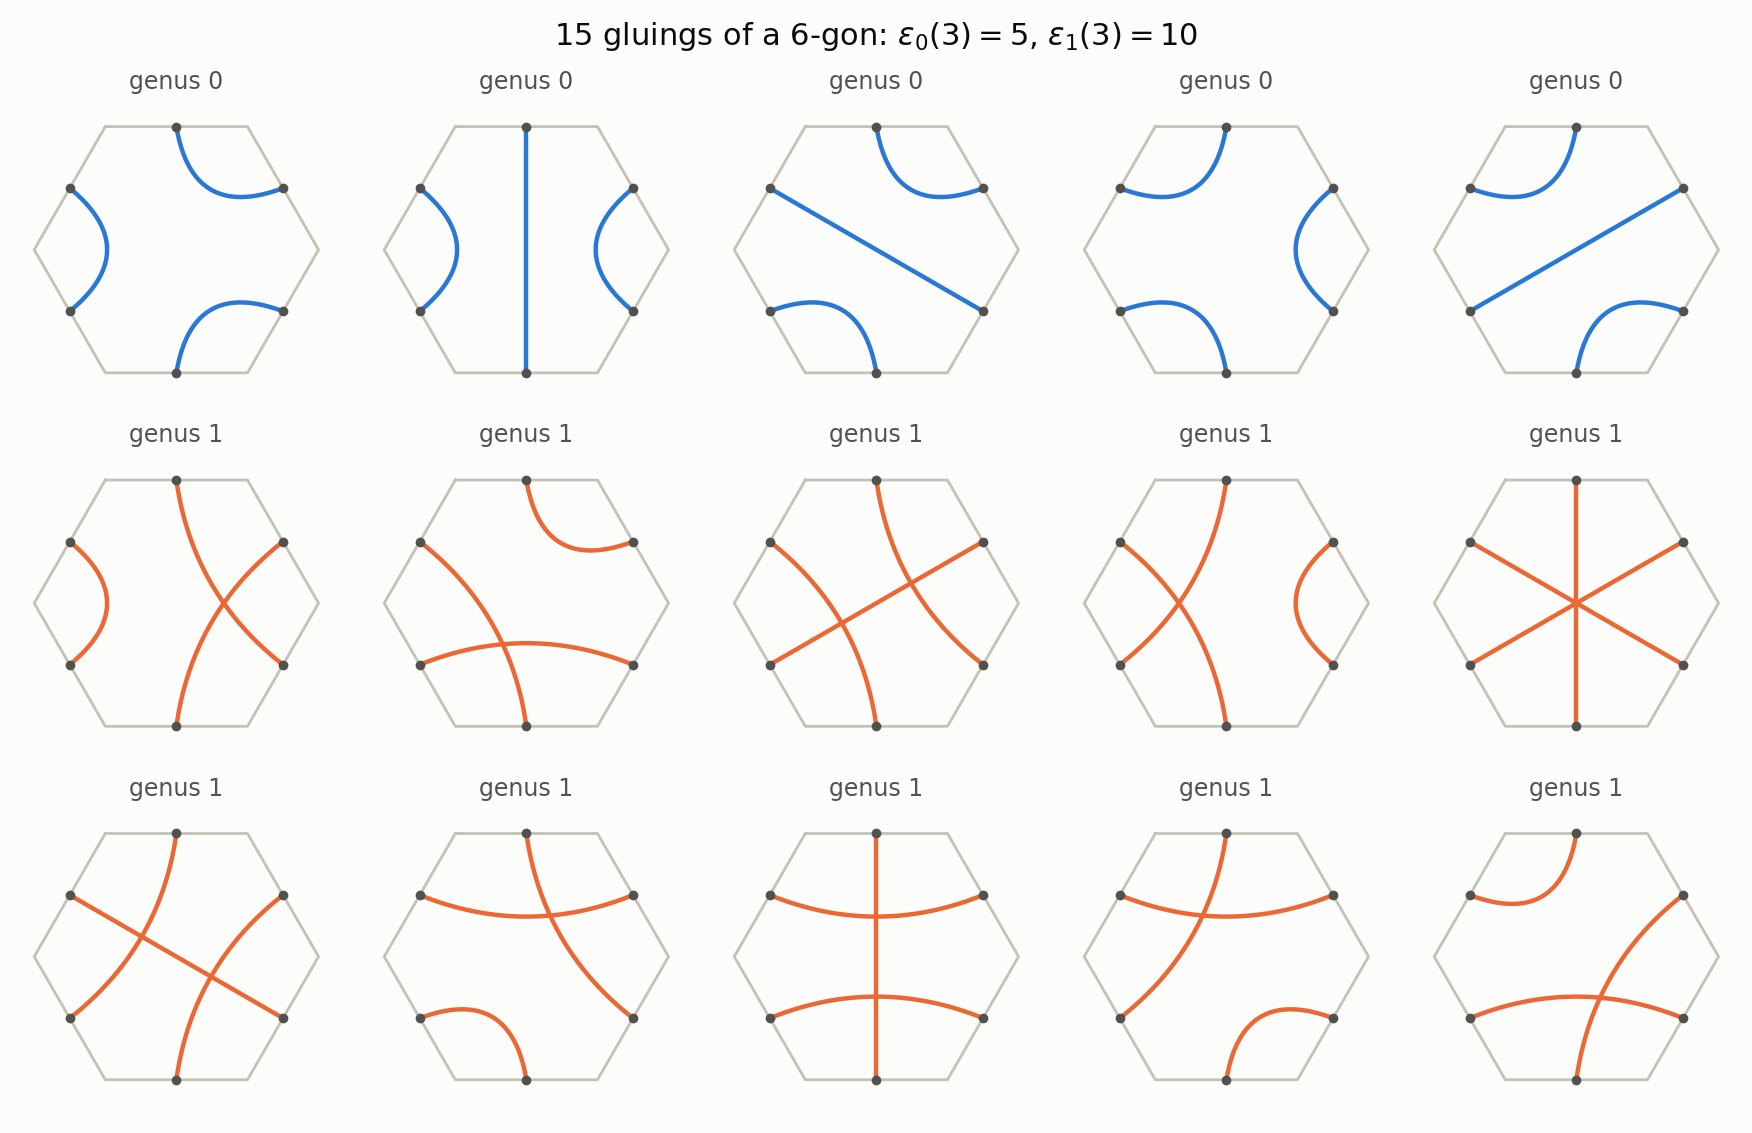

In [15]:
plot_sc.plot_chord_diagrams(3);

**Figure 5.2: Wick's theorem turns this count into moments.** For GUE, $E\,\frac1N \operatorname{tr} M^{2k} = \sum_g \epsilon_g(k)\,N^{-2g}$ holds *exactly*, as a finite sum. Each gluing contributes $N^{V - k - 1} = N^{-2g}$.
- **At $N = 1$** every gluing counts once, and the total is the Gaussian moment $(2k-1)!!$.
- **As $N \to \infty$** only the planar gluings survive: the Catalan numbers, i.e. the semicircle.

The bars are $\epsilon_g(k)$ from the Harer–Zagier recursion. The dots are Monte Carlo.

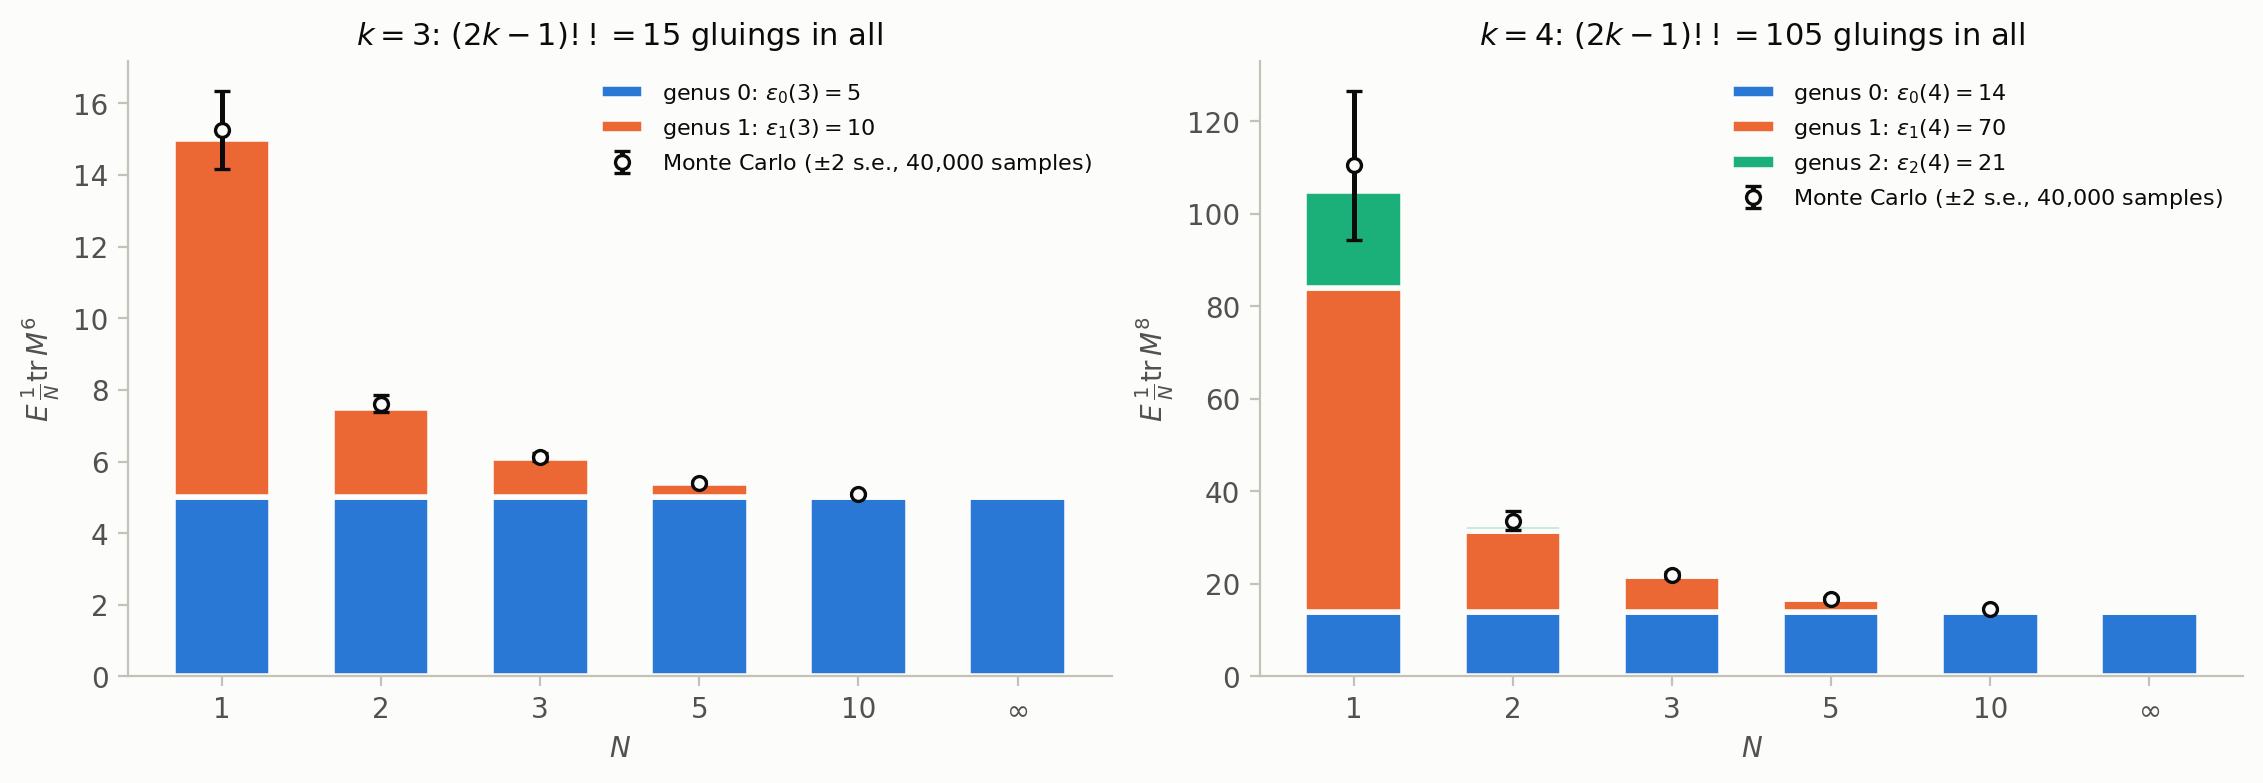

In [16]:
plot_sc.plot_genus_expansion(ks=(3, 4), ns=(1, 2, 3, 5, 10), size=40_000, rng=rng);

**Topological recursion: feed in a curve, get out the tower.** `sc.TopologicalRecursion` implements the Eynard–Orantin recursion for curves with a rational parametrization. You give it $x(z)$, $y(z)$ and the ramification points; the rest is residues. It is run here on two curves:
- **The Airy curve** $x = z^2/2$, $y = z$, the local model of §2. It gives the intersection numbers $\langle\tau_{d_1}\cdots\tau_{d_n}\rangle_g$ on $\overline{\mathcal M}_{g,n}$ that Witten conjectured and Kontsevich proved with a matrix integral.
- **The semicircle curve** $x = z + 1/z$, $y = \frac12(z - 1/z)$. There $\omega_{g,1} = W_g(x)\,dx$ is the generating function of the genus-$g$ gluings above.

Genus 2 on the semicircle curve takes a few seconds.

In [17]:
airy = sc.airy_curve()
rows = []
for g, n in [(0, 3), (1, 1), (0, 4), (1, 2), (2, 1), (0, 5), (1, 3), (2, 2), (3, 1)]:
  for ds, val in sc.intersection_numbers(airy, g, n).items():
    taus = r"\,".join(rf"\tau_{d}" for d in ds)
    rows.append(rf"| $({g}, {n})$ | $\langle {taus} \rangle_{g}$ | ${sp.latex(val)}$ |")
display(Markdown("| $(g, n)$ | intersection number | from the Airy curve |\n|---|---|---|\n" + "\n".join(rows)))

gue = sc.semicircle_curve()
zz = gue.z
W_of_z = {g: sp.factor(gue.omega(g, 1).subs(gue.zs[0], zz) / sp.diff(gue.x, zz)) for g in (1, 2)}
table = [r"| $g$ | $\epsilon_g(k)$, $k = 0, \dots, 6$, from the curve | Harer–Zagier recursion | $W_g$ in terms of $z$ |",
         "|---|---|---|---|"]
for g in (1, 2):
  table.append(f"| {g} | {sc.gluing_counts_from_curve(gue, g, 6)} | {[sc.harer_zagier(g, k) for k in range(7)]} "
               f"| ${sp.latex(W_of_z[g])}$ |")
display(Markdown("\n".join(table) + "\n\nPoles only at the ramification points $z = \\pm 1$, i.e. at the edges $x = \\pm 2$."))

| $(g, n)$ | intersection number | from the Airy curve |
|---|---|---|
| $(0, 3)$ | $\langle \tau_0\,\tau_0\,\tau_0 \rangle_0$ | $1$ |
| $(1, 1)$ | $\langle \tau_1 \rangle_1$ | $\frac{1}{24}$ |
| $(0, 4)$ | $\langle \tau_1\,\tau_0\,\tau_0\,\tau_0 \rangle_0$ | $1$ |
| $(1, 2)$ | $\langle \tau_1\,\tau_1 \rangle_1$ | $\frac{1}{24}$ |
| $(1, 2)$ | $\langle \tau_2\,\tau_0 \rangle_1$ | $\frac{1}{24}$ |
| $(2, 1)$ | $\langle \tau_4 \rangle_2$ | $\frac{1}{1152}$ |
| $(0, 5)$ | $\langle \tau_1\,\tau_1\,\tau_0\,\tau_0\,\tau_0 \rangle_0$ | $2$ |
| $(0, 5)$ | $\langle \tau_2\,\tau_0\,\tau_0\,\tau_0\,\tau_0 \rangle_0$ | $1$ |
| $(1, 3)$ | $\langle \tau_1\,\tau_1\,\tau_1 \rangle_1$ | $\frac{1}{12}$ |
| $(1, 3)$ | $\langle \tau_2\,\tau_1\,\tau_0 \rangle_1$ | $\frac{1}{12}$ |
| $(1, 3)$ | $\langle \tau_3\,\tau_0\,\tau_0 \rangle_1$ | $\frac{1}{24}$ |
| $(2, 2)$ | $\langle \tau_3\,\tau_2 \rangle_2$ | $\frac{29}{5760}$ |
| $(2, 2)$ | $\langle \tau_4\,\tau_1 \rangle_2$ | $\frac{1}{384}$ |
| $(2, 2)$ | $\langle \tau_5\,\tau_0 \rangle_2$ | $\frac{1}{1152}$ |
| $(3, 1)$ | $\langle \tau_7 \rangle_3$ | $\frac{1}{82944}$ |

| $g$ | $\epsilon_g(k)$, $k = 0, \dots, 6$, from the curve | Harer–Zagier recursion | $W_g$ in terms of $z$ |
|---|---|---|---|
| 1 | [0, 0, 1, 10, 70, 420, 2310] | [0, 0, 1, 10, 70, 420, 2310] | $\frac{z^{5}}{\left(z - 1\right)^{5} \left(z + 1\right)^{5}}$ |
| 2 | [0, 0, 0, 0, 21, 483, 6468] | [0, 0, 0, 0, 21, 483, 6468] | $\frac{21 z^{9} \left(z^{4} + 3 z^{2} + 1\right)}{\left(z - 1\right)^{11} \left(z + 1\right)^{11}}$ |

Poles only at the ramification points $z = \pm 1$, i.e. at the edges $x = \pm 2$.

**Figure 5.3: why the Airy function resums the genus expansion.** Near the edge, $W_g(2 + \delta) \sim \delta^{-(6g-1)/2}$. So the genus-$g$ term is

$$N^{-2g}\delta^{-(6g-1)/2} = \delta^{1/2}\,\big(N^{-2}\delta^{-3}\big)^g,$$

and the expansion is really a series in $N^{-2}\delta^{-3}$.
- **Far from the edge** the higher genera are negligible.
- **At $\delta \sim N^{-2/3}$** they are all the same size. Every one of them scales like $N^{-1/3} f_g(\xi)$ with $\xi = N^{2/3}\delta$, so the whole series must be summed. Its sum is the Airy kernel of §2.

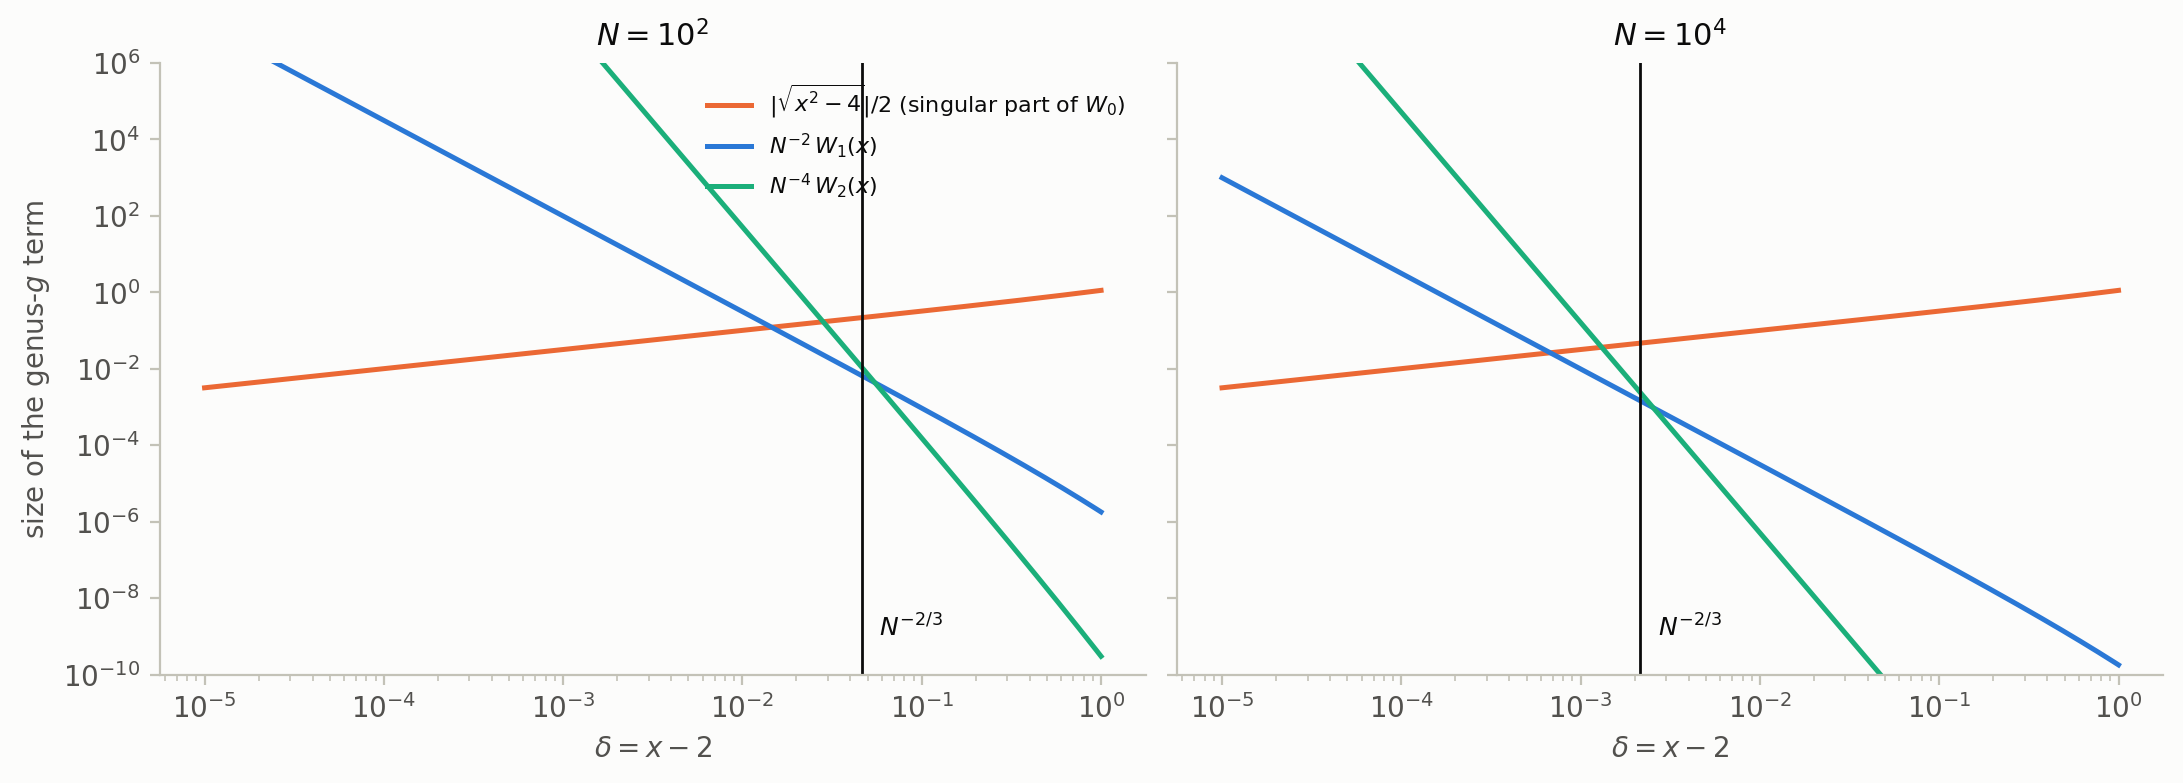

In [18]:
W = [lambda x: onp.sqrt(x * x - 4) / 2, sc.one_point_function(gue, 1), sc.one_point_function(gue, 2)]
sc.plot_genus_near_edge(W, ns=(10**2, 10**4));

## 6. Finite $N$: log-derivatives and finite free probability

**Figure 6.1: electrostatics.** $S(z) = \frac1n \operatorname{tr}(A - z)^{-1} = -\frac1n \frac{p'(z)}{p(z)}$. The conjugate $\overline{p'/p} = \sum_i 1/\overline{(z - \lambda_i)}$ is the 2D electric field of unit charges placed at the eigenvalues. Its zeros are the roots of $p'$: the equilibrium points between the charges. The equilibrium measure of §3 is the same force balance in the continuum, where the external field $V'$ balances $2W$ on the support.

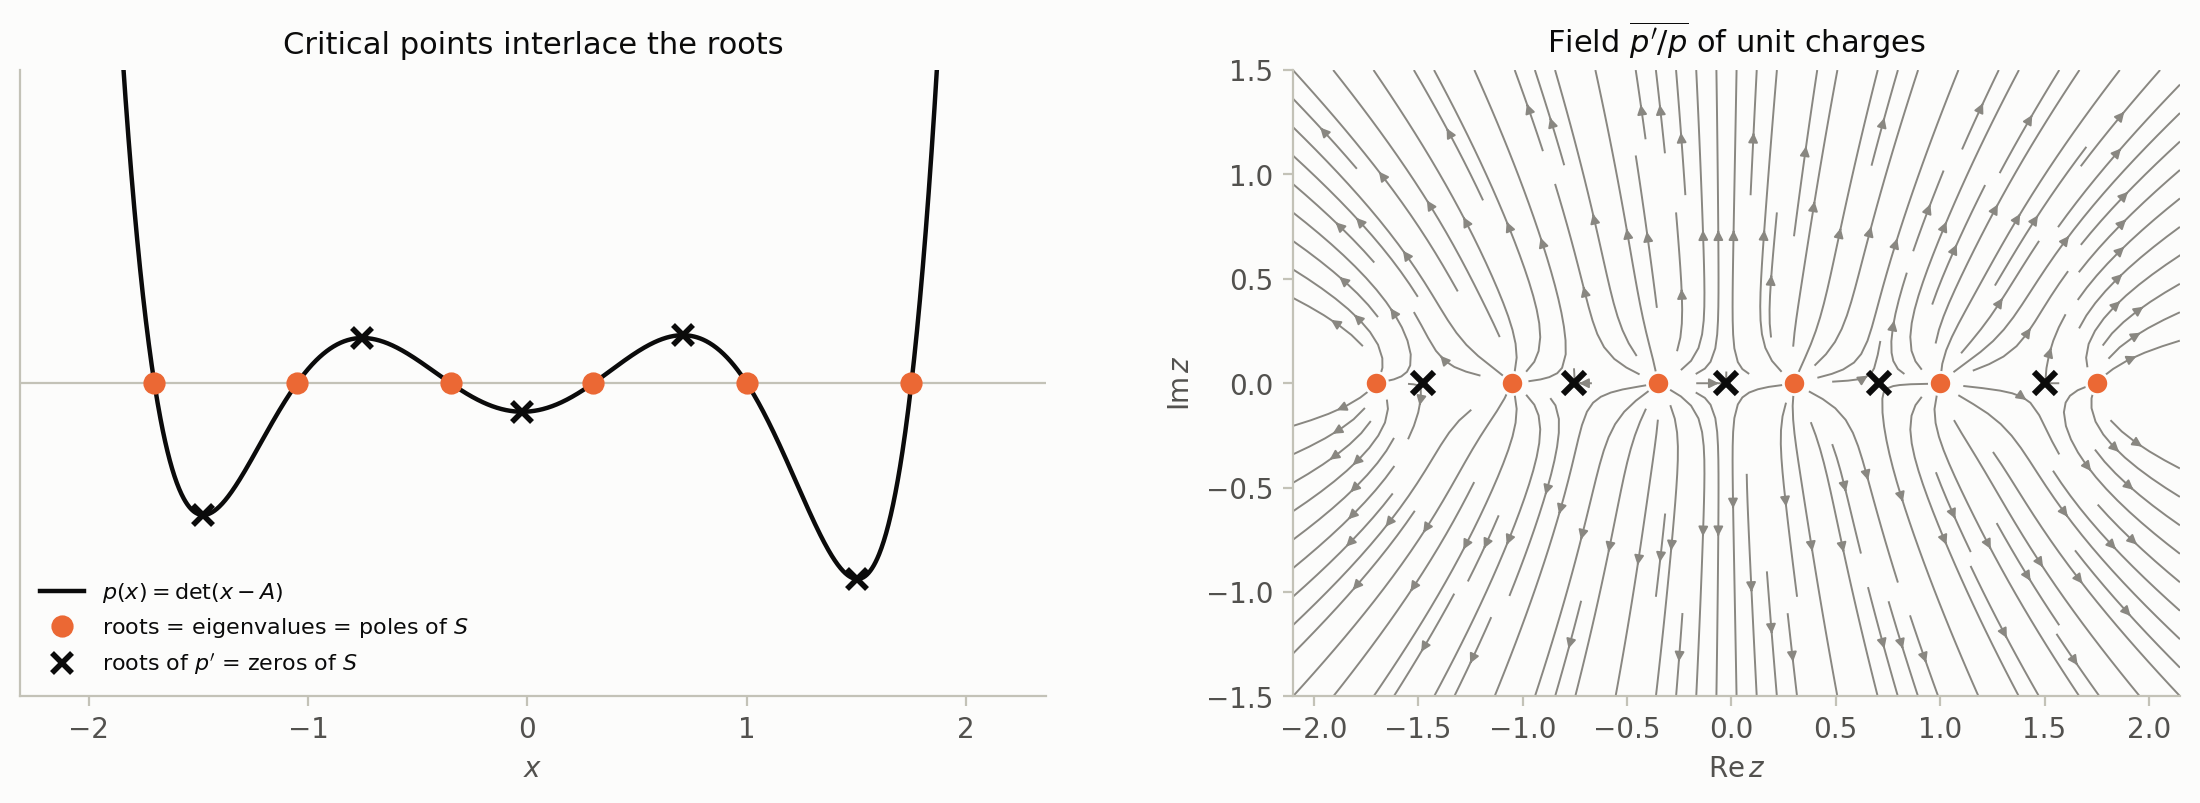

In [19]:
plot_sc.plot_electrostatics();

**Figure 6.2: expected characteristic polynomials.** Marcus–Spielman–Srivastava's finite free convolution $p \boxplus_n q = E_Q\det(x - A - QBQ^T)$ has a closed form in the coefficients. It preserves real-rootedness, and as $n \to \infty$ it becomes $\boxplus$.
- **Left.** Characteristic polynomials of random rotations scatter, but their average is the MSS polynomial, and its roots are real.
- **Right.** The roots of $(x^2 - 1)^{n/2} \boxplus_n (x^2 - 1)^{n/2}$ fill out the arcsine law of §4. The polynomials are computed exactly in rational arithmetic and their roots in extended precision.

largest |Im| of any root, n = 4, 8, 16, 32: ['0e+00', '0e+00', '0e+00', '0e+00']


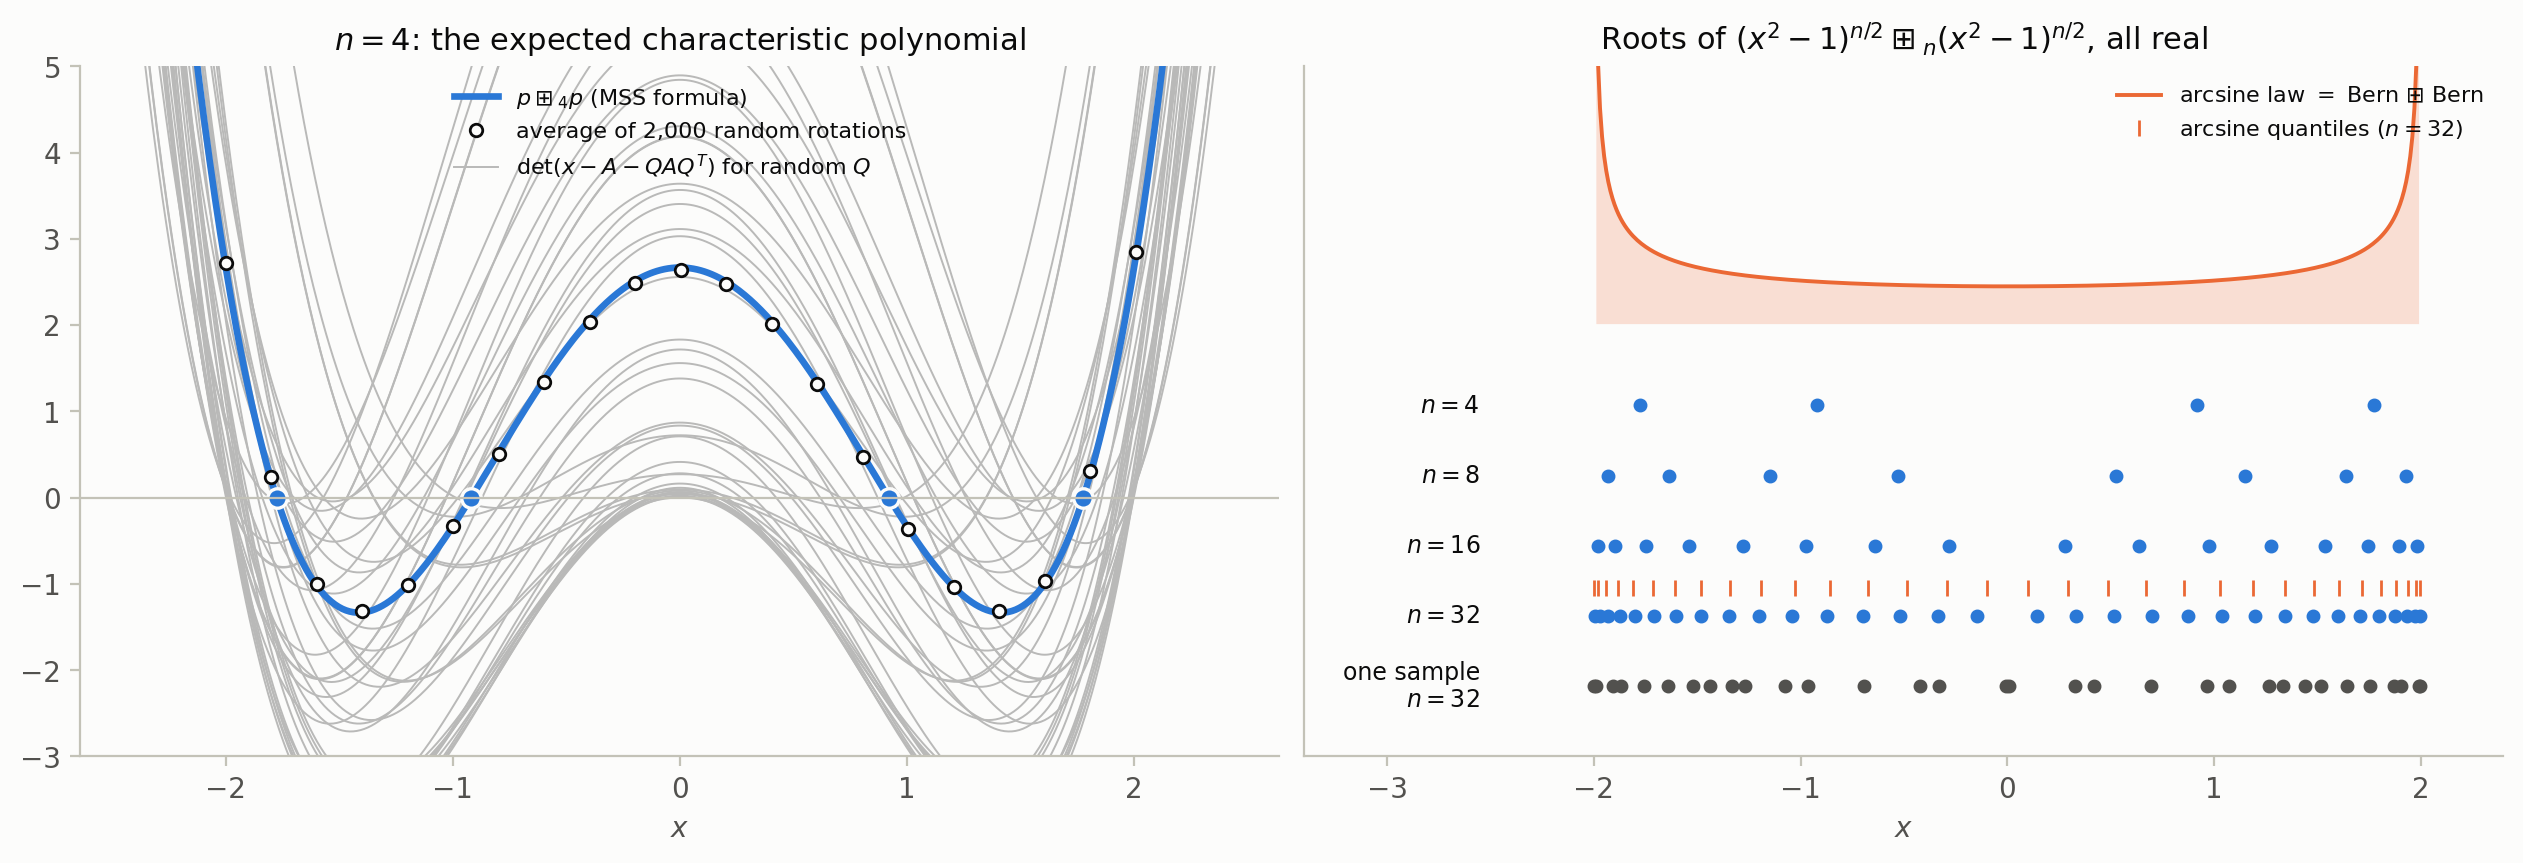

In [20]:
fig, rows = plot_sc.plot_finite_free(rng=rng)
print("largest |Im| of any root, n = 4, 8, 16, 32:", [f"{row[2]:.0e}" for row in rows[:-1]])

**Figure 6.3: interlacing families**, the step that led to Kadison–Singer.
- **Interlacing.** Each rank-one update $A + vv^T$ interlaces $\det(x - A)$: it has one root in every gap between eigenvalues of $A$ (grey lines) and one more above them.
- **The consequence.** Any average of these polynomials is real-rooted, with its roots in the same gaps. And some member of the family has its largest root no larger than the average's.
- **Kadison–Singer.** Marcus, Spielman and Srivastava apply this lemma over a whole tree of choices to show that a good choice exists.

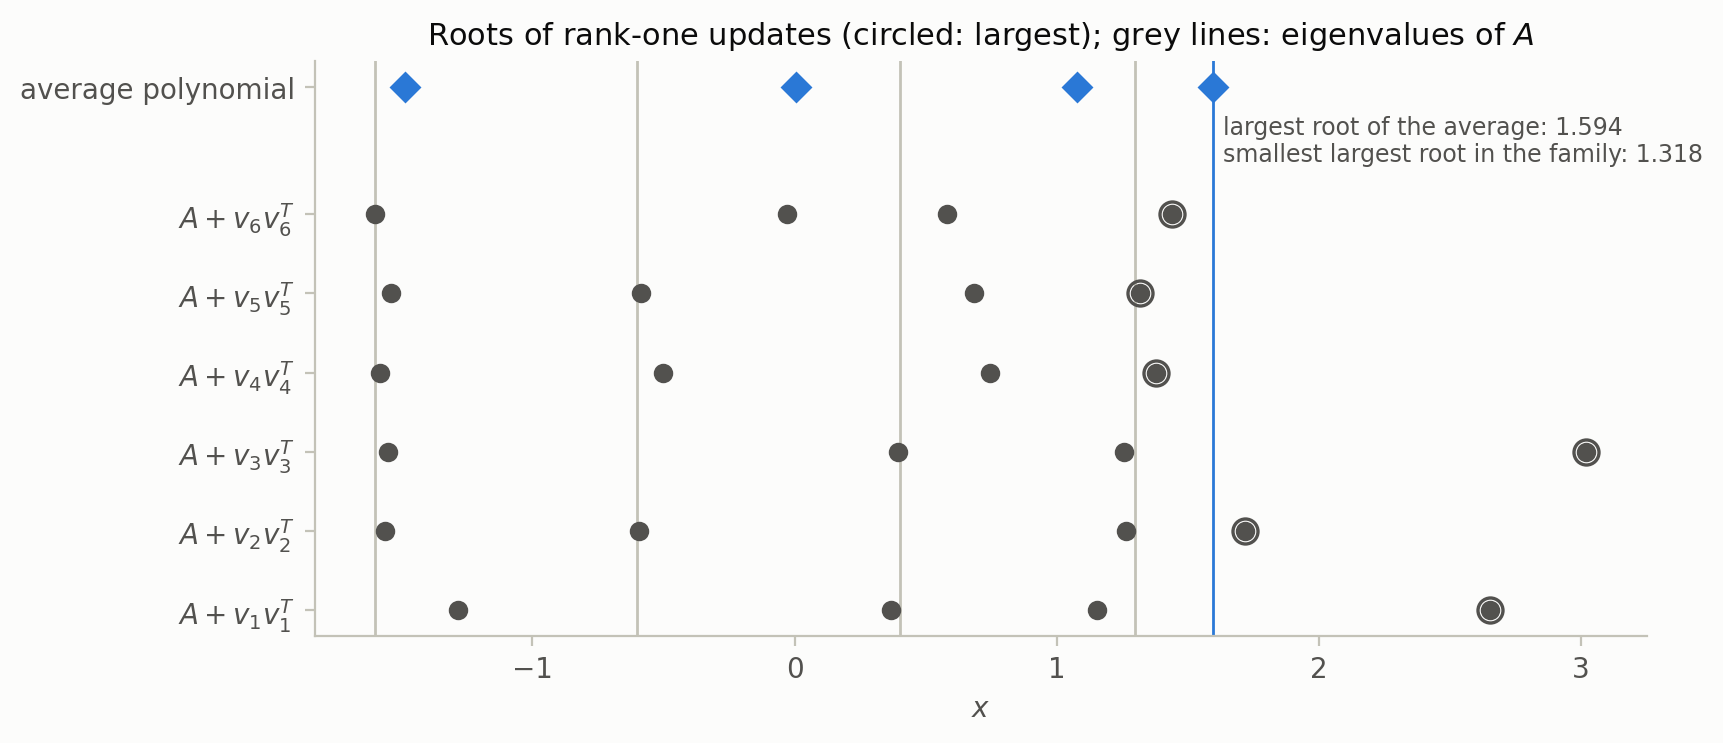

In [21]:
plot_sc.plot_interlacing(rng=3);

## The dictionary, and where each entry is drawn

| distribution | curve | figures |
|---|---|---|
| support $[-2, 2]$ | the cut, i.e. the image of $\lvert s\rvert = 1$, along which the two sheets are glued | 1.1, 1.2 |
| density $\rho$ | the jump of $s$ across the cut; the imaginary points of $y^2 = z^2 - 4$ | 1.4, 2.1 |
| finite $N$ | poles of $-p'/(Np)$, condensing into the cut | 1.3, 6.1 |
| square-root edges, $N^{-2/3}$, Airy, Tracy–Widom | a simple branch point, with local model $y^2 = x$ | 2.1, 2.2 |
| $k$ intervals | $2k$ branch points, genus $k - 1$: disk → sphere, cylinder → torus | 3.1, 3.2, 3.4 |
| filling fractions, equilibrium | A-periods (oval areas); a vanishing B-period (equal areas) | 3.3 |
| free convolution | a resultant of the R-curves | 4.1, 4.2 |
| $1/N^2$ corrections | gluings by genus; topological recursion on the curve | 5.1–5.3 |
| real-rootedness, interlacing | expected characteristic polynomials | 6.2, 6.3 |

Things to try:
- **Section 3.** Other potentials, e.g. `sc.QuarticModel(g=1, a=-2.2, t=0.1)`: a barely split support gives a long, thin torus.
- **Section 4.** Other atoms or variances, e.g. `sc.free_sum(sc.semicircle_poly(0.5), sc.bernoulli_poly(1))`.
- **Topological recursion.** Other rational curves: `sc.TopologicalRecursion(x, y, sigma, ramification, z)`.